<a href="https://colab.research.google.com/github/majo581/TALLERES/blob/main/Copia_de_Copia_de_trabajo_de_econometria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RELACIÓN ENTRE LOS INTENTOS DE SUICIDIOS Y LOS DELITOS EN COLOMBIA POR MUNICIPIOS EN 2024
##  Yuli Fernanda Ezquivel Martinez
## María José González serrano

# 1.Exportacion de datos
Datos sacados de:


*    https://www.policia.gov.co/estadistica-delictiva
*    https://www.datos.gov.co/Justicia-y-Derecho/Presuntos-Suicidios-Colombia-2015-a-2024-Cifras-de/f75u-mirk/about_data



SUBIR BASES DE DATOS QUE ESTAN LA CARPETA DATA EN GITHUB

In [ ]:
import pandas as pd

In [ ]:


df_suicidios = pd.read_excel('Presuntos_Suicidios._Colombia,_2015_a_2024._Cifras_definitivas_20260317.xlsx')

df_delitos = pd.read_excel('INFORMACIÓN_DE_DELITOS_A_NIVEL_DE_REGISTRO_AÑO_2024_0.xlsx')

##2.Limpiar los datos


### 2.1.Filtrar datos del 2024

In [ ]:
df_suicidios_2024 = df_suicidios[df_suicidios['Año del hecho'] == 2024]

print(f"Total de registros originales: {len(df_suicidios)}")
print(f"Registros solo de 2024: {len(df_suicidios_2024)}")

# Ver los primeros registros de 2024
df_suicidios_2024.head()

Total de registros originales: 26558
Registros solo de 2024: 3014


,ID,Año del hecho,Grupo de Edad Quinquenal,Grupo Mayor Menor de Edad,Grupo de Edad judicial,Ciclo Vital,Sexo de la victima,Estado Civil,País de Nacimiento,Escolaridad,...,Manera de Muerte,Mecanismo Causal de la Lesión Fatal,Diagnostico Topográfico de la Lesión Fatal,Razón del Suicidio,Localidad del Hecho,Ancestro Racial,Pueblo Indígena,Orientación Sexual,Identidad de Género,Transgénero
3945,23567,2024,(35 a 39),b) Mayores de Edad (>18 años),(35 a 39),(29 a 59) Adultez,Hombre,Soltero(a),Colombia,Sin información,...,2 Suicidios,Tóxico,Sin lesiones,Enfermedad mental,Chapinero,Mestizo,No aplica,No Sabe / No Informa,No Sabe / No Informa,No Sabe / No Informa
4014,23568,2024,(55 a 59),b) Mayores de Edad (>18 años),(55 a 59),(29 a 59) Adultez,Hombre,Soltero(a),Colombia,Educación media o secundaria alta,...,2 Suicidios,Generadores de asfixia,Trauma de cuello,Económicas,Kennedy,Mestizo,No aplica,No Sabe / No Informa,Masculino,No Sabe / No Informa
4194,23570,2024,(40 a 44),b) Mayores de Edad (>18 años),(40 a 44),(29 a 59) Adultez,Hombre,Soltero(a),Colombia,Sin información,...,2 Suicidios,Tóxico,Sin lesiones,Sin información,Usaquen,Mestizo,No aplica,No Sabe / No Informa,No Sabe / No Informa,No Sabe / No Informa
4329,23571,2024,(20 a 24),b) Mayores de Edad (>18 años),(20 a 24),(18 a 28) Juventud,Hombre,Soltero(a),Colombia,Educación media o secundaria alta,...,2 Suicidios,Generadores de asfixia,Trauma de cuello,Sin información,Kennedy,Mestizo,No aplica,No Sabe / No Informa,Masculino,No Sabe / No Informa
4385,23587,2024,(35 a 39),b) Mayores de Edad (>18 años),(35 a 39),(29 a 59) Adultez,Hombre,Soltero(a),Colombia,Sin información,...,2 Suicidios,Tóxico,Politraumatismo,Desamor,Sin información,Mestizo,No aplica,Heterosexual,Masculino,No Sabe / No Informa


### 2.2.Ver los años únicos en la base (puede haber años que no sean 2024)

In [ ]:
print("Años únicos en la base de suicidios:")
print(df_suicidios['Año del hecho'].value_counts().sort_index())

Años únicos en la base de suicidios:
Año del hecho
2015    2068
2016    2310
2017    2571
2018    2696
2019    2643
2020    2420
2021    2689
2022    2952
2023    3195
2024    3014
Name: count, dtype: int64


### 2.3.Ver si hay fechas que no sean de 2024 a pesar de tener año 2024

In [ ]:
print("Revisando fechas sospechosas en 2024:")
print(df_suicidios[df_suicidios['Año del hecho'] == 2024]['Mes del hecho'].value_counts())

Revisando fechas sospechosas en 2024:
Mes del hecho
Enero         285
Septiembre    279
Diciembre     267
Agosto        257
Noviembre     252
Julio         252
Marzo         245
Octubre       242
Mayo          240
Junio         234
Febrero       231
Abril         230
Name: count, dtype: int64


### 2.4.Verificar duplicados en la base de suicidios 2024

In [ ]:
duplicados = df_suicidios_2024.duplicated().sum()
print(f"Registros duplicados en Suicidios 2024: {duplicados}")

# Si hay duplicados, mostrarlos
if duplicados > 0:
    print("\nEjemplo de duplicados:")
    print(df_suicidios_2024[df_suicidios_2024.duplicated(keep=False)].head(10))

Registros duplicados en Suicidios 2024: 0


### 2.5.Eliminar NaN de la base de delitos

In [ ]:
df_delitos = pd.read_excel('INFORMACIÓN_DE_DELITOS_A_NIVEL_DE_REGISTRO_AÑO_2024_0.xlsx', skiprows=11)

# Limpiar
df_delitos = df_delitos.dropna(subset=['MUNICIPIO', 'DELITOS'], how='all')

palabras_clave = ['TOTAL', 'Fuente', 'Fecha', 'DELITOS OPERACIÓN']
for palabra in palabras_clave:
    mascara = df_delitos['DELITOS'].astype(str).str.contains(palabra, case=False, na=False)
    df_delitos = df_delitos[~mascara]

# Verificar
print(" BASE LIMPIA")
print(f"Registros finales: {len(df_delitos)}")
print("\nÚltimos 5 registros:")
print(df_delitos.tail(5))

 BASE LIMPIA
Registros finales: 834148

Últimos 5 registros:
                       ARMAS MEDIOS        DEPARTAMENTO        MUNICIPIO  \
834143                ARMA DE FUEGO               HUILA            Suaza   
834144                ARMA DE FUEGO              TOLIMA          Espinal   
834145          SIN EMPLEO DE ARMAS                META          Acacías   
834146  ARMA BLANCA / CORTOPUNZANTE  NORTE DE SANTANDER           Abrego   
834147                LLAVE MAESTRA           ATLÁNTICO  Puerto Colombia   

       FECHA HECHO     GENERO *AGRUPA EDAD PERSONA*  CODIGO DANE  \
834143  04/05/2024  MASCULINO               ADULTOS      41770.0   
834144  16/08/2024  MASCULINO               ADULTOS      73268.0   
834145  03/10/2024  MASCULINO               ADULTOS      50006.0   
834146  21/02/2024  MASCULINO               ADULTOS      54003.0   
834147  13/10/2024  MASCULINO               ADULTOS       8573.0   

                                 DELITOS   MES  CANTIDAD  
834143  ARTÍCU

In [ ]:
print(f"Registros de SUICIDIOS 2024: {len(df_suicidios_2024)}")
print(f"Registros de DELITOS: {len(df_delitos)}")

Registros de SUICIDIOS 2024: 3014
Registros de DELITOS: 834148


## 3.Agrupar delitos





In [ ]:
# ==========================================
# 1. DEFINIR LA FUNCIÓN DE CLASIFICACIÓN
# ==========================================
def clasificar_delito_final(texto):
    texto = str(texto).upper()

    if 'SECUESTRO' in texto:
        return 'Secuestro'
    elif 'HOMICIDIO' in texto or 'FEMINICIDIO' in texto:
        return 'Homicidios'
    elif 'HURTO' in texto or 'ABIGEATO' in texto:
        return 'Hurto'
    elif ('SEXUAL' in texto or
          'PROSTITUCION' in texto or
          'PROSTITUCIÓN' in texto or
          'PORNOGRAFIA' in texto or
          'PORNOGRAFÍA' in texto or
          'ACCESO CARNAL' in texto or
          'ACTO SEXUAL' in texto or
          'PROXENETISMO' in texto or
          'EXPLOTACION SEXUAL' in texto):
        return 'Delitos Sexuales'
    elif ('LESION' in texto or
          'PERDIDA ANATOMICA' in texto or
          'PÉRDIDA ANATÓMICA' in texto or
          'DEFORMIDAD' in texto or
          'INCAPACIDAD' in texto or
          'PERTURBACION' in texto or
          'PERTURBACIÓN' in texto or
          'VIOLENCIA INTRAFAMILIAR' in texto):
        return 'Lesiones Personales'
    elif ('EXTORSION' in texto or
          'TERRORISMO' in texto or
          'AMENAZAS' in texto or
          'OMISIÓN' in texto or
          'OMISION' in texto):
        return 'Otros Delitos'
    else:
        return 'Otros Delitos'

# ==========================================
# 2. CREAR LA COLUMNA CATEGORIA EN df_delitos (ORIGINAL)
# ==========================================
df_delitos['CATEGORIA'] = df_delitos['DELITOS'].apply(clasificar_delito_final)

print("✅ Columna CATEGORIA creada en df_delitos (DataFrame ORIGINAL)")
print(df_delitos[['DELITOS', 'CATEGORIA']].head(10))

# ==========================================
# 3. VERIFICAR DISTRIBUCIÓN
# ==========================================
print("\n=== DISTRIBUCIÓN DE CATEGORÍAS ===")
print(df_delitos['CATEGORIA'].value_counts())

✅ Columna CATEGORIA creada en df_delitos (DataFrame ORIGINAL)
                                             DELITOS   CATEGORIA
0  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
1  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
2  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
3  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
4  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
5  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
6  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
7  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
8  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
9  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios

=== DISTRIBUCIÓN DE CATEGORÍAS ===
CATEGORIA
Hurto                  436917
Lesiones Personales    274321
Otros Delitos           70510
Delitos Sexuales        31465
Homicidios              20622
Secuestro                 3

In [ ]:
total_categoria = (df_delitos.groupby('CATEGORIA')['CANTIDAD'].sum().sort_values(ascending=False))
print(total_categoria)

CATEGORIA
Hurto                  436917.0
Lesiones Personales    274321.0
Otros Delitos           70510.0
Delitos Sexuales        31465.0
Homicidios              20622.0
Secuestro                 313.0
Name: CANTIDAD, dtype: float64


##  4.Estadisticas generales de los delitos en los departamentos

###  4.1.delitos a nivel nacinal con departamentos

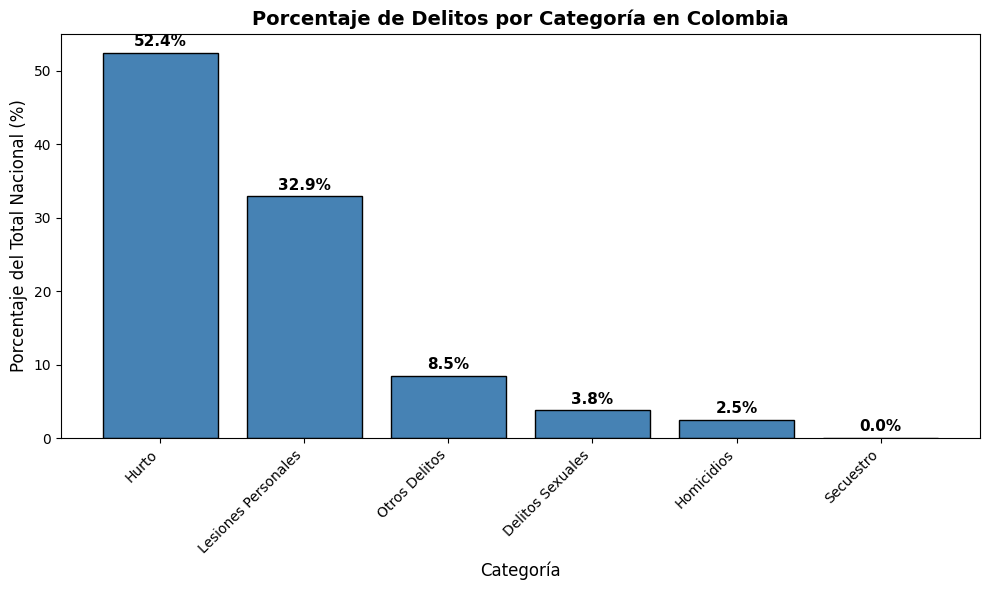

In [ ]:
import matplotlib.pyplot as plt

# Calcular porcentaje a nivel nacional
total_nacional = df_delitos['CANTIDAD'].sum()

porcentaje_categoria = (
    df_delitos
    .groupby('CATEGORIA')['CANTIDAD']
    .sum()
    .sort_values(ascending=False)
)

porcentaje_categoria = (
    porcentaje_categoria / total_nacional
) * 100

# Gráfico
plt.figure(figsize=(10, 6))

bars = plt.bar(
    porcentaje_categoria.index,
    porcentaje_categoria.values,
    color='steelblue',
    edgecolor='black'
)

plt.title(
    'Porcentaje de Delitos por Categoría en Colombia',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Porcentaje del Total Nacional (%)', fontsize=12)

plt.xticks(rotation=45, ha='right')

# Valores encima de barras
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### 4.2.Ver la categoría que más afecta a cada departamento

In [ ]:
# Agrupar por departamento y categoría (usando df_delitos_filtrado)
delitos_por_depto = df_delitos.groupby(['DEPARTAMENTO', 'CATEGORIA'])['CANTIDAD'].sum().reset_index()

# Ver top por departamento
print("TOP 10 DEPARTAMENTOS CON MÁS DELITOS:")
top_deptos = delitos_por_depto.groupby('DEPARTAMENTO')['CANTIDAD'].sum().sort_values(ascending=False).head(10)
print(top_deptos)

TOP 10 DEPARTAMENTOS CON MÁS DELITOS:
DEPARTAMENTO
CUNDINAMARCA    301569.0
ANTIOQUIA       104620.0
VALLE            81390.0
SANTANDER        35671.0
ATLÁNTICO        31000.0
BOLÍVAR          26663.0
TOLIMA           25990.0
NARIÑO           22680.0
HUILA            22165.0
META             21849.0
Name: CANTIDAD, dtype: float64


In [ ]:
categoria_top = delitos_por_depto.loc[
    delitos_por_depto.groupby('DEPARTAMENTO')['CANTIDAD'].idxmax()
]
print("\n CATEGORÍA PRINCIPAL POR DEPARTAMENTO:")
print(categoria_top.sort_values('CANTIDAD', ascending=False).head(10))


 CATEGORÍA PRINCIPAL POR DEPARTAMENTO:
     DEPARTAMENTO            CATEGORIA  CANTIDAD
72   CUNDINAMARCA                Hurto  181921.0
7       ANTIOQUIA                Hurto   56840.0
171         VALLE                Hurto   41852.0
154     SANTANDER                Hurto   16267.0
19      ATLÁNTICO                Hurto   15589.0
101         HUILA                Hurto   12067.0
25        BOLÍVAR                Hurto   11817.0
119        NARIÑO                Hurto   11617.0
113          META                Hurto   11146.0
166        TOLIMA  Lesiones Personales   11026.0


###  4.3.Total de delitos por categoria

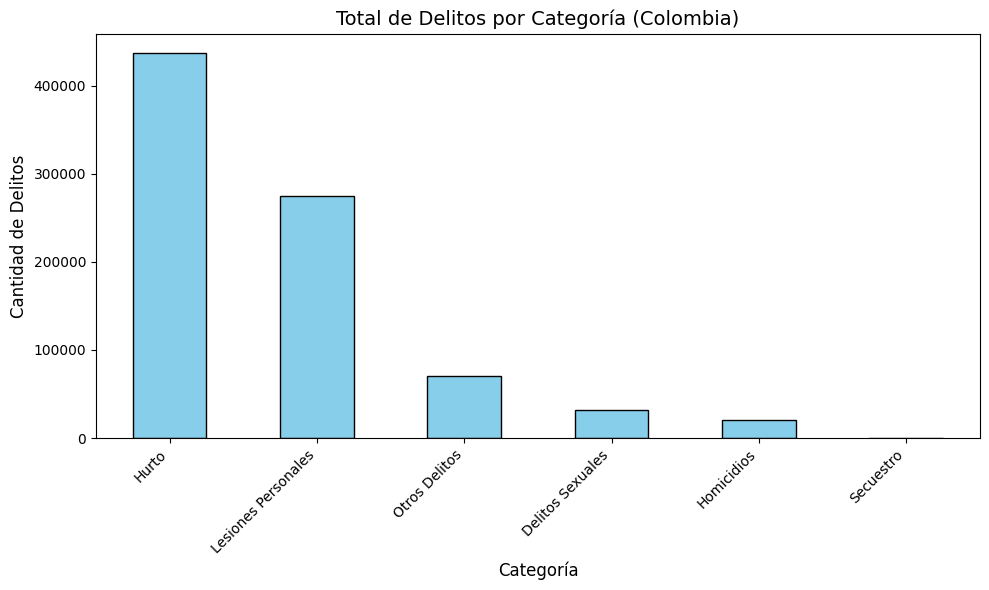

In [ ]:
import matplotlib.pyplot as plt

# Configurar estilo
plt.style.use('default')

# Gráfico de barras
categorias_total = df_delitos.groupby('CATEGORIA')['CANTIDAD'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
categorias_total.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total de Delitos por Categoría (Colombia)', fontsize=14)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Cantidad de Delitos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



###  4.4.Top 5 departamentos por tipo de delito

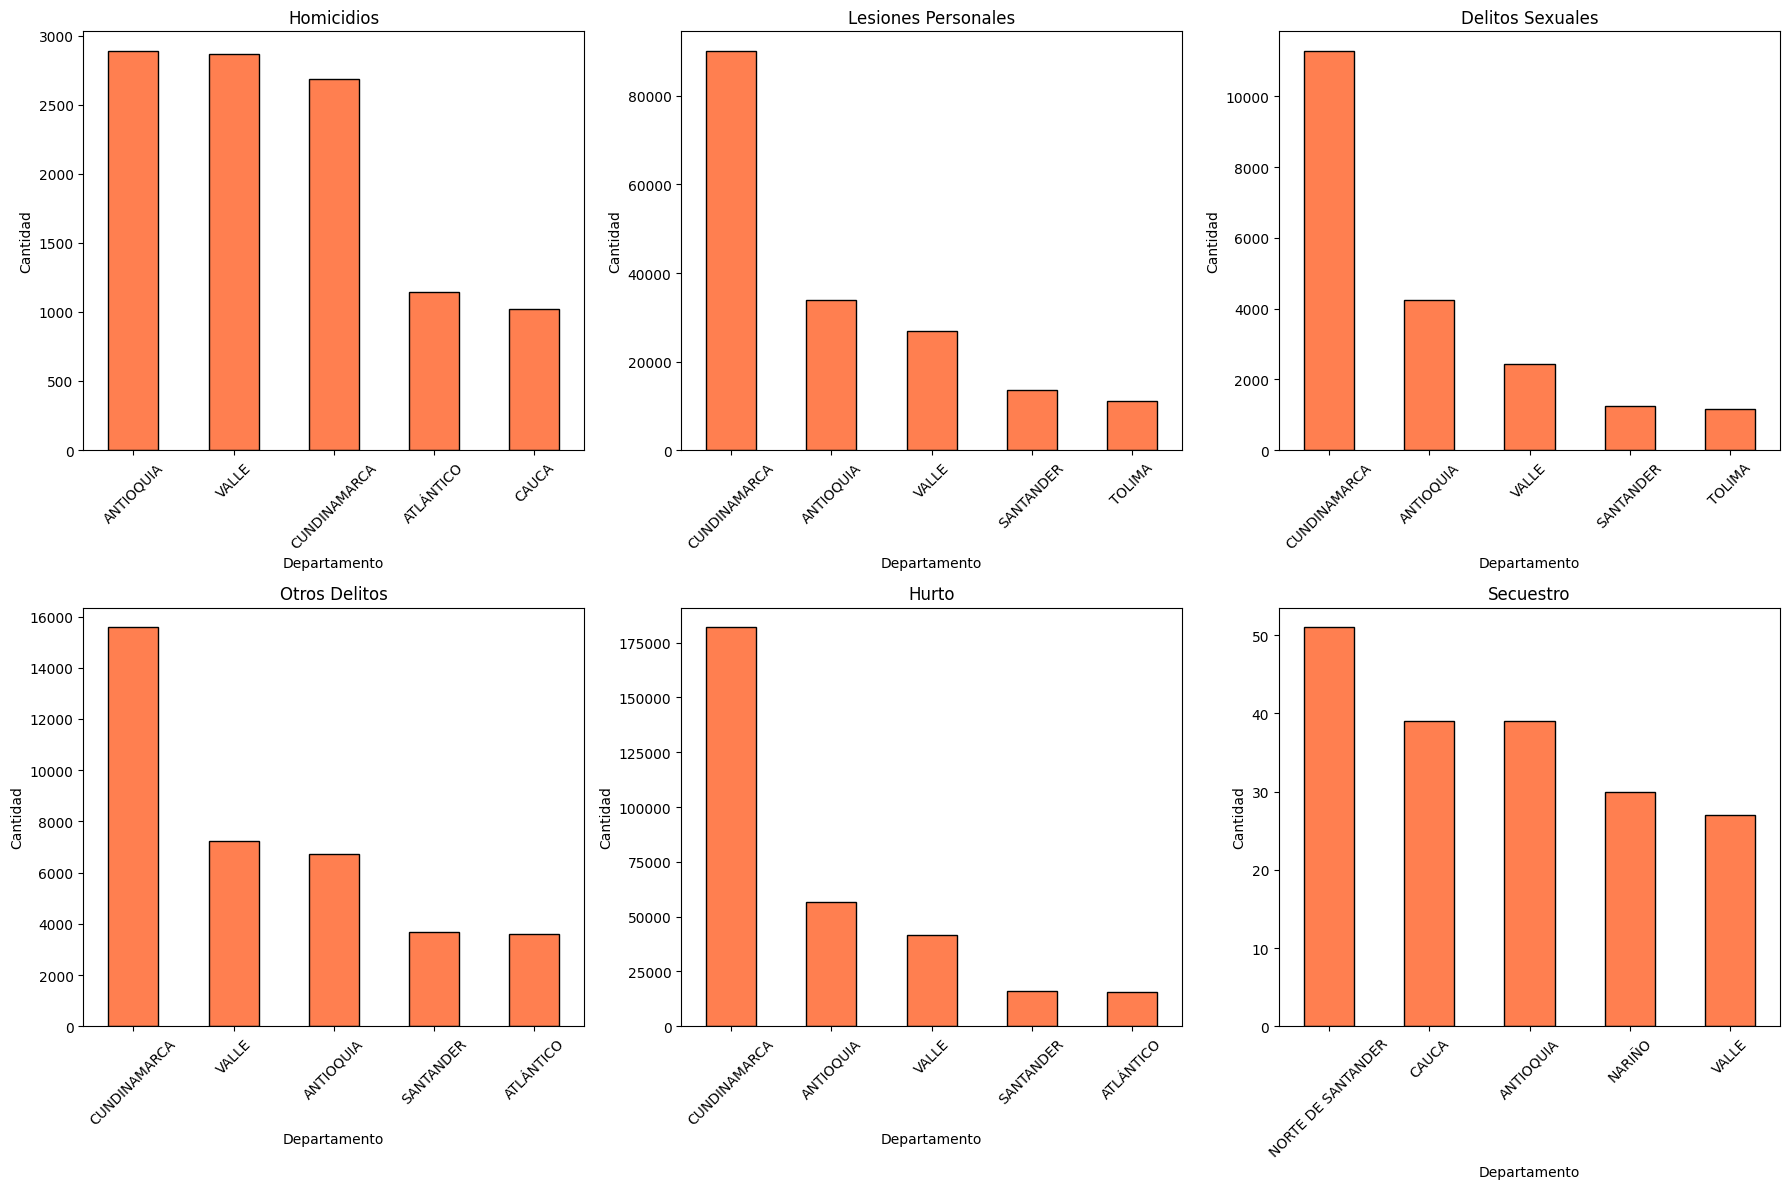

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, categoria in enumerate(df_delitos['CATEGORIA'].unique()):
    datos = df_delitos[df_delitos['CATEGORIA'] == categoria]
    top = datos.groupby('DEPARTAMENTO')['CANTIDAD'].sum().sort_values(ascending=False).head(5)

    top.plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
    axes[i].set_title(f'{categoria}', fontsize=12)
    axes[i].set_xlabel('Departamento')
    axes[i].set_ylabel('Cantidad')
    axes[i].tick_params(axis='x', rotation=45)

# Ocultar el último subplot si sobra
if len(df_delitos['CATEGORIA'].unique()) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### 4.5.Top 15 departamentos com mas delitos en mapa de calor

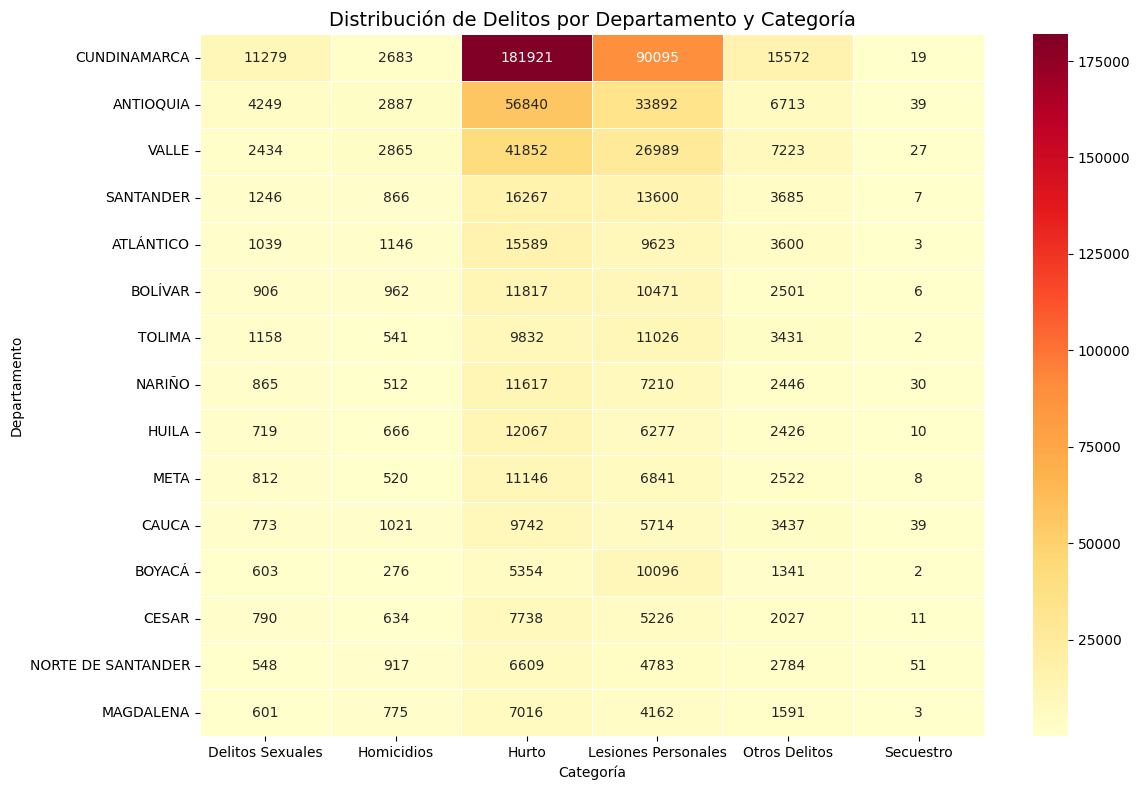

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

matriz_delitos = df_delitos.pivot_table(
    values='CANTIDAD',
    index='DEPARTAMENTO',
    columns='CATEGORIA',
    aggfunc='sum',
    fill_value=0
)

top_deptos = matriz_delitos.sum(axis=1).sort_values(ascending=False).head(15).index
matriz_top = matriz_delitos.loc[top_deptos]

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_top, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Distribución de Delitos por Departamento y Categoría', fontsize=14)
plt.xlabel('Categoría')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

##  5.Estadisticas generales por municipios

###  5.1.Comparar municipios de ambas bases

In [ ]:
print("="*60)
print("MUNICIPIOS EN BASE DE SUICIDIOS 2024")
print("="*60)

municipios_sui = sorted(df_suicidios_2024['Municipio del hecho DANE'].unique())
print(f"Total: {len(municipios_sui)} municipios\n")

for i, mun in enumerate(municipios_sui, 1):
    print(f"{i}. {mun}")

MUNICIPIOS EN BASE DE SUICIDIOS 2024
Total: 611 municipios

1. Abejorral
2. Acacías
3. Acandí
4. Acevedo
5. Agrado
6. Agua de Dios
7. Aguachica
8. Aguadas
9. Agustín Codazzi
10. Aipe
11. Albania
12. Albán
13. Alcalá
14. Algeciras
15. Almaguer
16. Alvarado
17. Amalfi
18. Ambalema
19. Anapoima
20. Andalucía
21. Andes
22. Angelópolis
23. Anolaima
24. Anorí
25. Anserma
26. Anzoátegui
27. Anzá
28. Apartadó
29. Apía
30. Aquitania
31. Aranzazu
32. Aratoca
33. Arauca
34. Arauquita
35. Arboleda
36. Arcabuco
37. Argelia
38. Ariguaní
39. Arjona
40. Armenia
41. Armero Guayabal
42. Astrea
43. Ataco
44. Atrato
45. Ayapel
46. Balboa
47. Barbacoas
48. Barbosa
49. Barrancabermeja
50. Barrancas
51. Barranquilla
52. Becerril
53. Belalcázar
54. Bello
55. Belmira
56. Belén de Bajirá
57. Belén de Umbría
58. Betania
59. Bochalema
60. Bogotá, D.C.
61. Bojacá
62. Bojayá
63. Bolívar
64. Bosconia
65. Boyacá
66. Bucaramanga
67. Bucarasica
68. Buenaventura
69. Buenavista
70. Buesaco
71. Bugalagrande
72. Busbanzá
7

In [ ]:
print("="*60)
print(" MUNICIPIOS EN BASE DE DELITOS")
print("="*60)

# Eliminar NaN y convertir a string
municipios_del = sorted([str(m) for m in df_delitos['MUNICIPIO'].unique() if pd.notna(m)])
print(f"Total: {len(municipios_del)} municipios\n")

for i, mun in enumerate(municipios_del, 1):
    print(f"{i}. {mun}")

 MUNICIPIOS EN BASE DE DELITOS
Total: 1021 municipios

1. Abejorral
2. Abrego
3. Abriaquí
4. Acacías
5. Acandí
6. Acevedo
7. Achí
8. Agrado
9. Agua de Dios
10. Aguachica
11. Aguada
12. Aguadas
13. Aguazul
14. Agustín Codazzi
15. Aipe
16. Albania
17. Albán
18. Alcalá
19. Aldana
20. Alejandría
21. Algarrobo
22. Algeciras
23. Almaguer
24. Almeida
25. Alpujarra
26. Altamira
27. Alto Baudó
28. Altos del Rosario
29. Alvarado
30. Amagá
31. Amalfi
32. Ambalema
33. Anapoima
34. Ancuyá
35. Andalucía
36. Andes
37. Angelópolis
38. Angostura
39. Anolaima
40. Anorí
41. Anserma
42. Ansermanuevo
43. Anza
44. Anzoátegui
45. Apartadó
46. Apulo
47. Apía
48. Aquitania
49. Aracataca
50. Aranzazu
51. Aratoca
52. Arauca (CT)
53. Arauquita
54. Arbeláez
55. Arboleda
56. Arboledas
57. Arboletes
58. Arcabuco
59. Arenal
60. Argelia
61. Ariguaní
62. Arjona
63. Armenia
64. Armenia (CT)
65. Armero
66. Arroyohondo
67. Astrea
68. Ataco
69. Atrato
70. Ayapel
71. Bagadó
72. Bahía Solano
73. Bajo Baudó
74. Balboa
75. Bar

###  5.2.Obtener municipios comunes

### 5.5.Verificar que ambas tienen los mismos municipios

In [ ]:
df_suicidios_2024['Municipio del hecho DANE'] = (
    df_suicidios_2024['Municipio del hecho DANE']
    .str.upper()
    .str.strip()
)

df_delitos['MUNICIPIO'] = (
    df_delitos['MUNICIPIO']
    .str.upper()
    .str.strip()
)

/tmp/ipykernel_1554/3131937562.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_suicidios_2024['Municipio del hecho DANE'] = (


In [ ]:
solo_delitos = set( df_delitos['MUNICIPIO'].dropna()) - set(df_suicidios_2024['Municipio del hecho DANE'].dropna())

print(sorted(solo_delitos))

['ABREGO', 'ABRIAQUÍ', 'ACHÍ', 'AGUADA', 'AGUAZUL', 'ALDANA', 'ALEJANDRÍA', 'ALGARROBO', 'ALMEIDA', 'ALPUJARRA', 'ALTAMIRA', 'ALTO BAUDÓ', 'ALTOS DEL ROSARIO', 'AMAGÁ', 'ANCUYÁ', 'ANGOSTURA', 'ANSERMANUEVO', 'ANZA', 'APULO', 'ARACATACA', 'ARAUCA (CT)', 'ARBELÁEZ', 'ARBOLEDAS', 'ARBOLETES', 'ARENAL', 'ARMENIA (CT)', 'ARMERO', 'ARROYOHONDO', 'BAGADÓ', 'BAHÍA SOLANO', 'BAJO BAUDÓ', 'BARANOA', 'BARAYA', 'BARICHARA', 'BARRANCA DE UPÍA', 'BARRANCO DE LOBA', 'BARRANQUILLA (CT)', 'BELTRÁN', 'BELÉN', 'BELÉN DE LOS ANDAQUIES', 'BERBEO', 'BETULIA', 'BETÉITIVA', 'BITUIMA', 'BOAVITA', 'BOGOTÁ D.C. (CT)', 'BRICEÑO', 'BUCARAMANGA (CT)', 'BUENOS AIRES', 'BURITICÁ', 'CABRERA', 'CABUYARO', 'CACHIRÁ', 'CAIMITO', 'CALARCA', 'CALI (CT)', 'CALIFORNIA', 'CAMPO DE LA CRUZ', 'CAMPOHERMOSO', 'CANTAGALLO', 'CAPARRAPÍ', 'CAQUEZA', 'CARACOLÍ', 'CARAMANTA', 'CARCASÍ', 'CARMEN DEL DARIEN', 'CARTAGENA (CT)', 'CARURU', 'CEPITÁ', 'CERRITO', 'CERRO SAN ANTONIO', 'CHALÁN', 'CHAMEZA', 'CHARALÁ', 'CHARTA', 'CHIMÁ', 'CHINAV

In [ ]:
solo_suicidios = set(df_suicidios_2024['Municipio del hecho DANE'].dropna()) - set(df_delitos['MUNICIPIO'].dropna())

print(sorted(solo_suicidios))

['ANZÁ', 'ARAUCA', 'ARMERO GUAYABAL', 'BARRANQUILLA', 'BELÉN DE BAJIRÁ', 'BOGOTÁ, D.C.', 'BUCARAMANGA', 'CALARCÁ', 'CALI', 'CARMEN DEL DARIÉN', 'CARTAGENA DE INDIAS', 'CONSACÁ', 'CÁCHIRA', 'CÁQUEZA', 'CÚCUTA', 'DONMATÍAS', 'FÓMEQUE', 'GÁMBITA', 'IBAGUÉ', 'INÍRIDA', 'ITAGÜÍ', 'LETICIA', 'MANAURE BALCÓN DEL CESAR', 'MANIZALES', 'MEDELLÍN', 'MITÚ', 'MOCOA', 'MONTERÍA', 'NEIVA', 'PASTO', 'PEREIRA', 'POPAYÁN', 'PUERTO CARREÑO', 'QUIBDÓ', 'RIOHACHA', 'SAN ANDRÉS DE SOTAVENTO', 'SAN ANDRÉS DE TUMACO', 'SAN JOSÉ DEL GUAVIARE', 'SAN JUAN DE RIOSECO', 'SAN LUIS DE CUBARRAL', 'SAN PEDRO DE LOS MILAGROS', 'SAN SEBASTIÁN DE MARIQUITA', 'SAN VICENTE FERRER', 'SANTA FÉ DE ANTIOQUIA', 'SANTA MARTA', 'SIN INFORMACIÓN', 'SINCELEJO', 'SONSÓN', 'TORIBÍO', 'TUNJA', 'VALLEDUPAR', 'VILLA DE SAN DIEGO DE UBATÉ', 'VILLAVICENCIO', 'YOPAL', 'ÁBREGO']


In [ ]:
import unicodedata
import re

def limpiar_municipio(texto):

    texto = str(texto).upper().strip()

    # quitar tildes
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

    # quitar cosas entre parentesis
    texto = re.sub(r'\(.*?\)', '', texto)

    # quitar comas y puntos
    texto = texto.replace(',', '')
    texto = texto.replace('.', '')

    # arreglos específicos
    reemplazos = {
        'BOGOTA DC': 'BOGOTA',
        'BOGOTA D C': 'BOGOTA',
        'CARTAGENA DE INDIAS': 'CARTAGENA',
        'ARMERO GUAYABAL': 'ARMERO',
        'DONMATIAS': 'DON MATIAS',
        'SANTA FE DE ANTIOQUIA': 'SANTAFE DE ANTIOQUIA',
        'SAN ANDRES DE SOTAVENTO': 'SAN ANDRES SOTAVENTO',
        'SAN JUAN DE RIOSECO': 'SAN JUAN DE RIO SECO',
        'VILLA DE SAN DIEGO DE UBATE': 'VILLA DE SAN DIEGO DE UBATE'
    }

    texto = reemplazos.get(texto, texto)

    # quitar espacios extra
    texto = ' '.join(texto.split())

    return texto

In [ ]:
df_suicidios_2024.loc[:, 'Municipio del hecho DANE'] = (df_suicidios_2024['Municipio del hecho DANE'].apply(limpiar_municipio))

In [ ]:
import numpy as np

# =========================
# LIMPIAR SUICIDIOS
# =========================
df_suicidios_2024.loc[:, 'Municipio del hecho DANE'] = (
    df_suicidios_2024['Municipio del hecho DANE']
    .replace({
        'SAN LUIS DE CUBARRAL': 'CUBARRAL',
        'MANAURE BALCON DEL CESAR': 'MANAURE',
        'BELEN DE BAJIRA': 'BELEN DE LOS ANDAQUIES',
        'SAN SEBASTIAN DE MARIQUITA': 'MARIQUITA',
        'SAN VICENTE FERRER': 'SAN VICENTE',
        'SIN INFORMACION': np.nan
    })
)

# =========================
# LIMPIAR DELITOS
# =========================
df_delitos.loc[:, 'MUNICIPIO'] = (
    df_delitos['MUNICIPIO']
    .replace({
        'SAN VICENTE': 'SAN VICENTE',
        'MARIQUITA': 'MARIQUITA',
        'CUBARRAL': 'CUBARRAL',
        'MANAURE': 'MANAURE',
        'BELEN DE LOS ANDAQUIES': 'BELEN DE LOS ANDAQUIES'
    })
)

# =========================
# ELIMINAR VACÍOS
# =========================
df_suicidios_2024 = df_suicidios_2024.dropna(
    subset=['Municipio del hecho DANE']
)

In [ ]:
df_delitos.loc[:, 'MUNICIPIO'] = (df_delitos['MUNICIPIO'].apply(limpiar_municipio))

In [ ]:
solo_suicidios = set(
    df_suicidios_2024['Municipio del hecho DANE']
) - set(
    df_delitos['MUNICIPIO']
)

print(solo_suicidios)

{'SAN PEDRO DE LOS MILAGROS'}


In [ ]:
df_suicidios_2024 = df_suicidios_2024[
    df_suicidios_2024['Municipio del hecho DANE'] != 'SAN PEDRO DE LOS MILAGROS']

In [ ]:
set(df_suicidios_2024['Municipio del hecho DANE']) == set(df_delitos['MUNICIPIO'])

False

In [ ]:
solo_suicidios = set(
    df_suicidios_2024['Municipio del hecho DANE']
) - set(
    df_delitos['MUNICIPIO']
)

solo_delitos = set(
    df_delitos['MUNICIPIO']
) - set(
    df_suicidios_2024['Municipio del hecho DANE']
)

print("SOLO SUICIDIOS:", solo_suicidios)
print("SOLO DELITOS:", solo_delitos)

SOLO SUICIDIOS: set()
SOLO DELITOS: {'BARRANCA DE UPIA', 'ULLOA', 'SAN ANDRES DE CUERQUIA', 'OSPINA', 'JUNIN', 'LOPEZ', 'VENTAQUEMADA', 'ALTAMIRA', 'LEJANIAS', 'SAN EDUARDO', 'FUQUENE', 'MUZO', 'ARACATACA', 'EL ROSARIO', 'GUATAVITA', 'SAN MATEO', 'SANTA LUCIA', 'CHARTA', 'CANTAGALLO', 'SAN MIGUEL DE SEMA', 'POTOSI', 'FLORIAN', 'CUNDAY', 'SAN MARTIN DE LOBA', 'COGUA', 'TARSO', 'NOVITA', 'TERUEL', 'PUERTO RONDON', 'PUERTO NARE', 'SOATA', 'SUTAMARCHAN', 'CAMPOHERMOSO', 'LA MACARENA', 'MACHETA', 'TOGUI', 'TESALIA', 'ABRIAQUI', 'TORO', 'RISARALDA', 'EL CALVARIO', 'EL PAUJIL', 'SAN JUANITO', 'BELTRAN', 'GUATAPE', 'VIRACACHA', 'IZA', 'DURANIA', 'MURINDO', 'RAGONVALIA', 'PANQUEBA', 'QUETAME', 'TUTAZA', 'ALDANA', 'TAMESIS', 'NORCASIA', 'EL GUACAMAYO', 'GAMEZA', 'IQUIRA', 'OIBA', 'PUERTO NARINO', 'SAN JOAQUIN', 'GUAVATA', 'ALTO BAUDO', 'QUIPAMA', 'BERBEO', 'PANDI', 'EL AGUILA', 'VERSALLES', 'JERUSALEN', 'ALEJANDRIA', 'CHOACHI', 'TARAZA', 'NUQUI', 'MARULANDA', 'ORTEGA', 'EL TABLON DE GOMEZ', 'TOP

In [ ]:
municipios_comunes = set(df_suicidios_2024['Municipio del hecho DANE']) & set(df_delitos['MUNICIPIO'])

df_suicidios_2024 = df_suicidios_2024[
    df_suicidios_2024['Municipio del hecho DANE'].isin(municipios_comunes)]

df_delitos = df_delitos[
    df_delitos['MUNICIPIO'].isin(municipios_comunes)]

In [ ]:
print(df_suicidios_2024['Municipio del hecho DANE'].nunique())

print(df_delitos['MUNICIPIO'].nunique())

609
609


In [ ]:
set(df_suicidios_2024['Municipio del hecho DANE']) == set(df_delitos['MUNICIPIO'])

True

### 5.6.Agrupar delitos filtrados por municipio y categoría

In [ ]:
print("=== COLUMNAS AHORA ===")
print(df_delitos.columns.tolist())

print("\n=== PRIMERAS FILAS ===")
print(df_delitos[['DELITOS', 'CATEGORIA']].head(10))

=== COLUMNAS AHORA ===
['ARMAS MEDIOS', 'DEPARTAMENTO', 'MUNICIPIO', 'FECHA HECHO', 'GENERO', '*AGRUPA EDAD PERSONA*', 'CODIGO DANE', 'DELITOS', 'MES', 'CANTIDAD', 'CATEGORIA']

=== PRIMERAS FILAS ===
                                             DELITOS   CATEGORIA
0  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
1  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
2  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
3  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
4  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
5  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
6  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
7  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
8  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios
9  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...  Homicidios


###  5.7.Top 20 municipios con mas delitos en Colombia

In [ ]:
print(df_delitos[['MUNICIPIO', 'DELITOS', 'CANTIDAD']].head(20))

        MUNICIPIO                                            DELITOS  CANTIDAD
0        MEDELLIN  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...       1.0
1        MEDELLIN  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...       1.0
2        VALDIVIA  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...       1.0
3   ZONA BANANERA  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...       1.0
4          AMALFI  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...       1.0
5          ZARZAL  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...       1.0
6        CAUCASIA  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...       1.0
7        RIOSUCIO  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...       1.0
8          ITAGUI  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...       1.0
9        MEDELLIN  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...       1.0
11         IBAGUE  ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...       1.0
12    PUERTO ASIS  ARTÍCULO 109. HOMICIDIO CULPOSO (

In [ ]:
top20_general = (  df_delitos.groupby('MUNICIPIO')['CANTIDAD']  .sum()  .sort_values(ascending=False)  .head(20))

print(top20_general)

MUNICIPIO
BOGOTA             248535.0
MEDELLIN            60706.0
CALI                48905.0
BARRANQUILLA        19386.0
CARTAGENA           18627.0
VILLAVICENCIO       14236.0
IBAGUE              14110.0
BUCARAMANGA         13988.0
PASTO               13744.0
SOACHA              13597.0
NEIVA               11429.0
POPAYAN              9639.0
SANTA MARTA          9535.0
CUCUTA               9087.0
VALLEDUPAR           8584.0
PEREIRA              7816.0
BELLO                7662.0
PALMIRA              6902.0
SOLEDAD              5685.0
BARRANCABERMEJA      5550.0
Name: CANTIDAD, dtype: float64


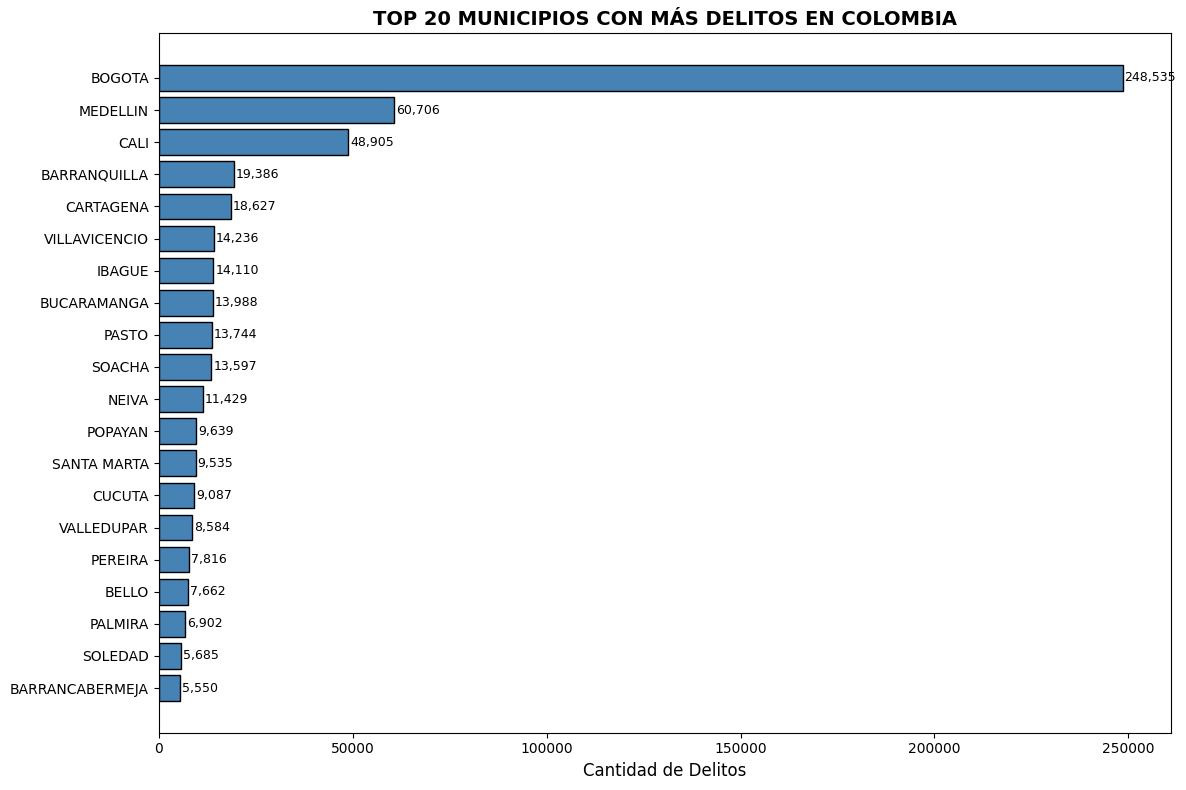

In [ ]:
import matplotlib.pyplot as plt

# Top 20 municipios con más delitos
top20_general = (df_delitos.groupby('MUNICIPIO')['CANTIDAD'].sum().sort_values(ascending=False).head(20))

plt.figure(figsize=(12, 8))

bars = plt.barh(
    range(len(top20_general)),
    top20_general.values,
    color='steelblue',
    edgecolor='black'
)

plt.yticks(range(len(top20_general)), top20_general.index)

plt.xlabel('Cantidad de Delitos', fontsize=12)

plt.title(
    'TOP 20 MUNICIPIOS CON MÁS DELITOS EN COLOMBIA',
    fontsize=14,
    fontweight='bold'
)

plt.gca().invert_yaxis()

# Agregar valores
for bar, val in zip(bars, top20_general.values):

    plt.text(
        val + 500,
        bar.get_y() + bar.get_height()/2,
        f'{int(val):,}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

###  5.8.Top 15 municipios-porcentaje total de delitos en Colombia

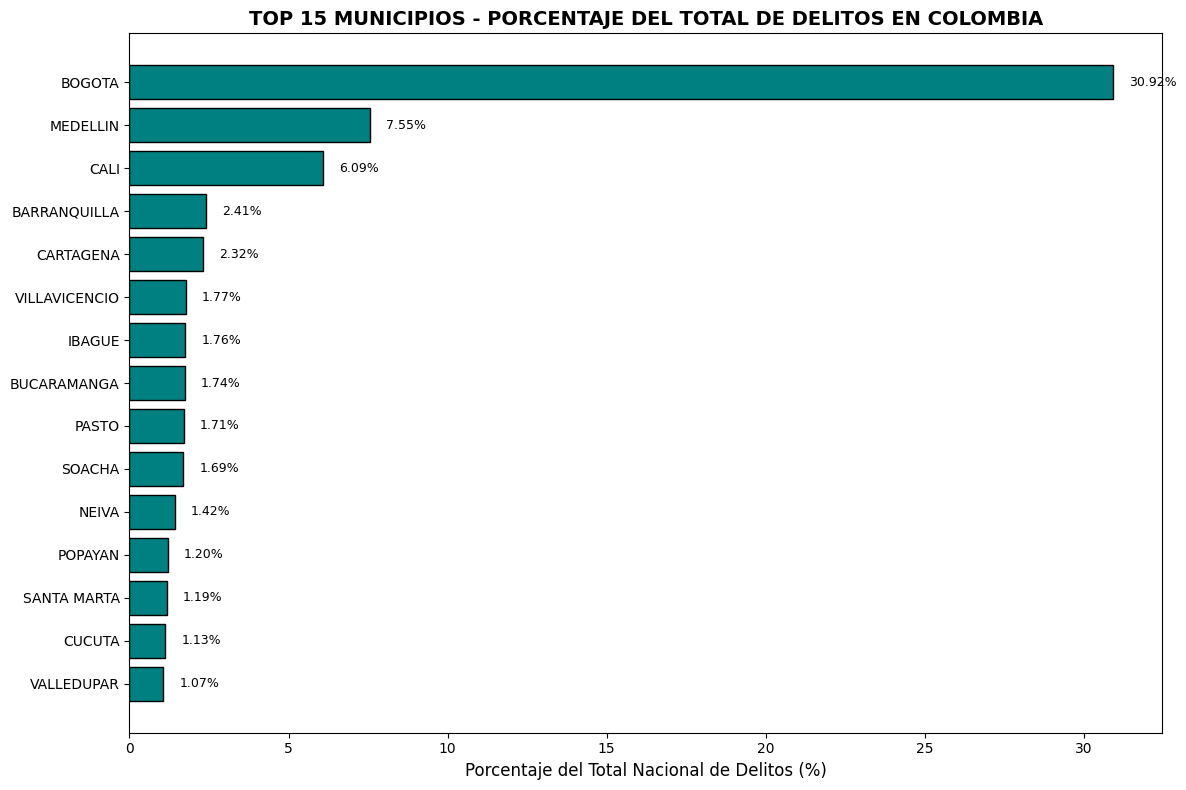


 Los 5 municipios con mayor porcentaje concentran: 49.29% de todos los delitos


In [ ]:
# Calcular porcentaje de cada municipio sobre el total nacional
total_nacional = df_delitos['CANTIDAD'].sum()
top15 = df_delitos.groupby('MUNICIPIO')['CANTIDAD'].sum().sort_values(ascending=False).head(15)
top15_porcentaje = (top15 / total_nacional) * 100

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top15_porcentaje)), top15_porcentaje.values, color='teal', edgecolor='black')
plt.yticks(range(len(top15_porcentaje)), top15_porcentaje.index)
plt.xlabel('Porcentaje del Total Nacional de Delitos (%)', fontsize=12)
plt.title('TOP 15 MUNICIPIOS - PORCENTAJE DEL TOTAL DE DELITOS EN COLOMBIA', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Agregar valores
for i, (bar, val) in enumerate(zip(bars, top15_porcentaje.values)):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.2f}%',
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n Los 5 municipios con mayor porcentaje concentran: {top15_porcentaje.head(5).sum():.2f}% de todos los delitos")

### 5.9.Delitos por categoria

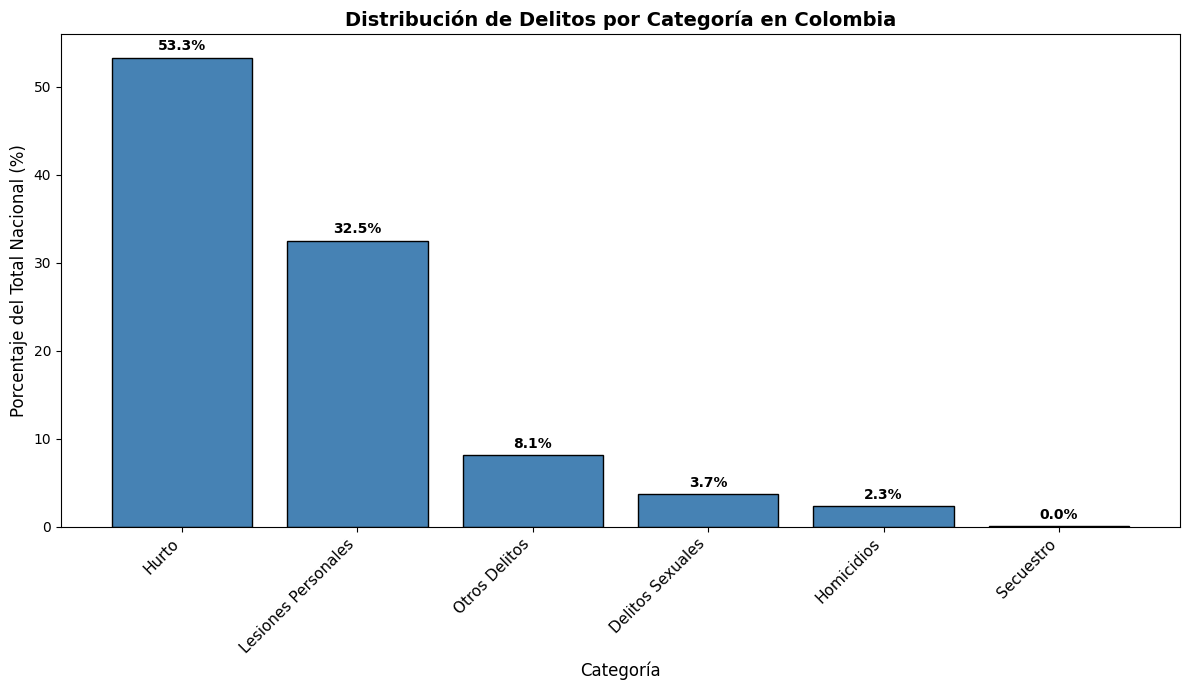

In [ ]:
import matplotlib.pyplot as plt

# Calcular porcentajes
total_nacional = df_delitos['CANTIDAD'].sum()
porcentaje_categoria = df_delitos.groupby('CATEGORIA')['CANTIDAD'].sum().sort_values(ascending=False)
porcentaje_categoria = (porcentaje_categoria / total_nacional) * 100

# Gráfico de barras
plt.figure(figsize=(12, 7))
bars = plt.bar(porcentaje_categoria.index, porcentaje_categoria.values,
               color='steelblue', edgecolor='black')

plt.title('Distribución de Delitos por Categoría en Colombia', fontsize=14, fontweight='bold')
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Porcentaje del Total Nacional (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)

# Agregar valores en las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

###  5.10.Top 5 municipios por categoria

In [ ]:
# Top 5 por categoría (con los datos filtrados)
for categoria in df_delitos['CATEGORIA'].unique():
    top = df_delitos[df_delitos['CATEGORIA'] == categoria]
    top = top.sort_values('CANTIDAD', ascending=False).head(5)
    print(f"\n{'='*50}")
    print(f"TOP 5 MUNICIPIOS - {categoria}")
    print('='*50)
    for i, row in top.iterrows():
        print(f"{row['MUNICIPIO']}: {int(row['CANTIDAD']):,} delitos")


TOP 5 MUNICIPIOS - Homicidios
MEDELLIN: 1 delitos
MEDELLIN: 1 delitos
MEDELLIN: 1 delitos
VALDIVIA: 1 delitos
ZONA BANANERA: 1 delitos

TOP 5 MUNICIPIOS - Lesiones Personales
SOGAMOSO: 1 delitos
PASTO: 1 delitos
IPIALES: 1 delitos
COVENAS: 1 delitos
RESTREPO: 1 delitos

TOP 5 MUNICIPIOS - Delitos Sexuales
BOGOTA: 1 delitos
SAN ANDRES DE TUMACO: 1 delitos
SAN ANDRES DE TUMACO: 1 delitos
SAMANIEGO: 1 delitos
BOGOTA: 1 delitos

TOP 5 MUNICIPIOS - Otros Delitos
QUIBDO: 1 delitos
BOGOTA: 1 delitos
BARRANCABERMEJA: 1 delitos
TABIO: 1 delitos
TABIO: 1 delitos

TOP 5 MUNICIPIOS - Hurto
PUERTO COLOMBIA: 1 delitos
MAGANGUE: 1 delitos
TUNJA: 1 delitos
BUCARAMANGA: 1 delitos
MAGANGUE: 1 delitos

TOP 5 MUNICIPIOS - Secuestro
SAN ANDRES DE TUMACO: 1 delitos
SARAVENA: 1 delitos
BUCARAMANGA: 1 delitos
OCANA: 1 delitos
PURACE: 1 delitos


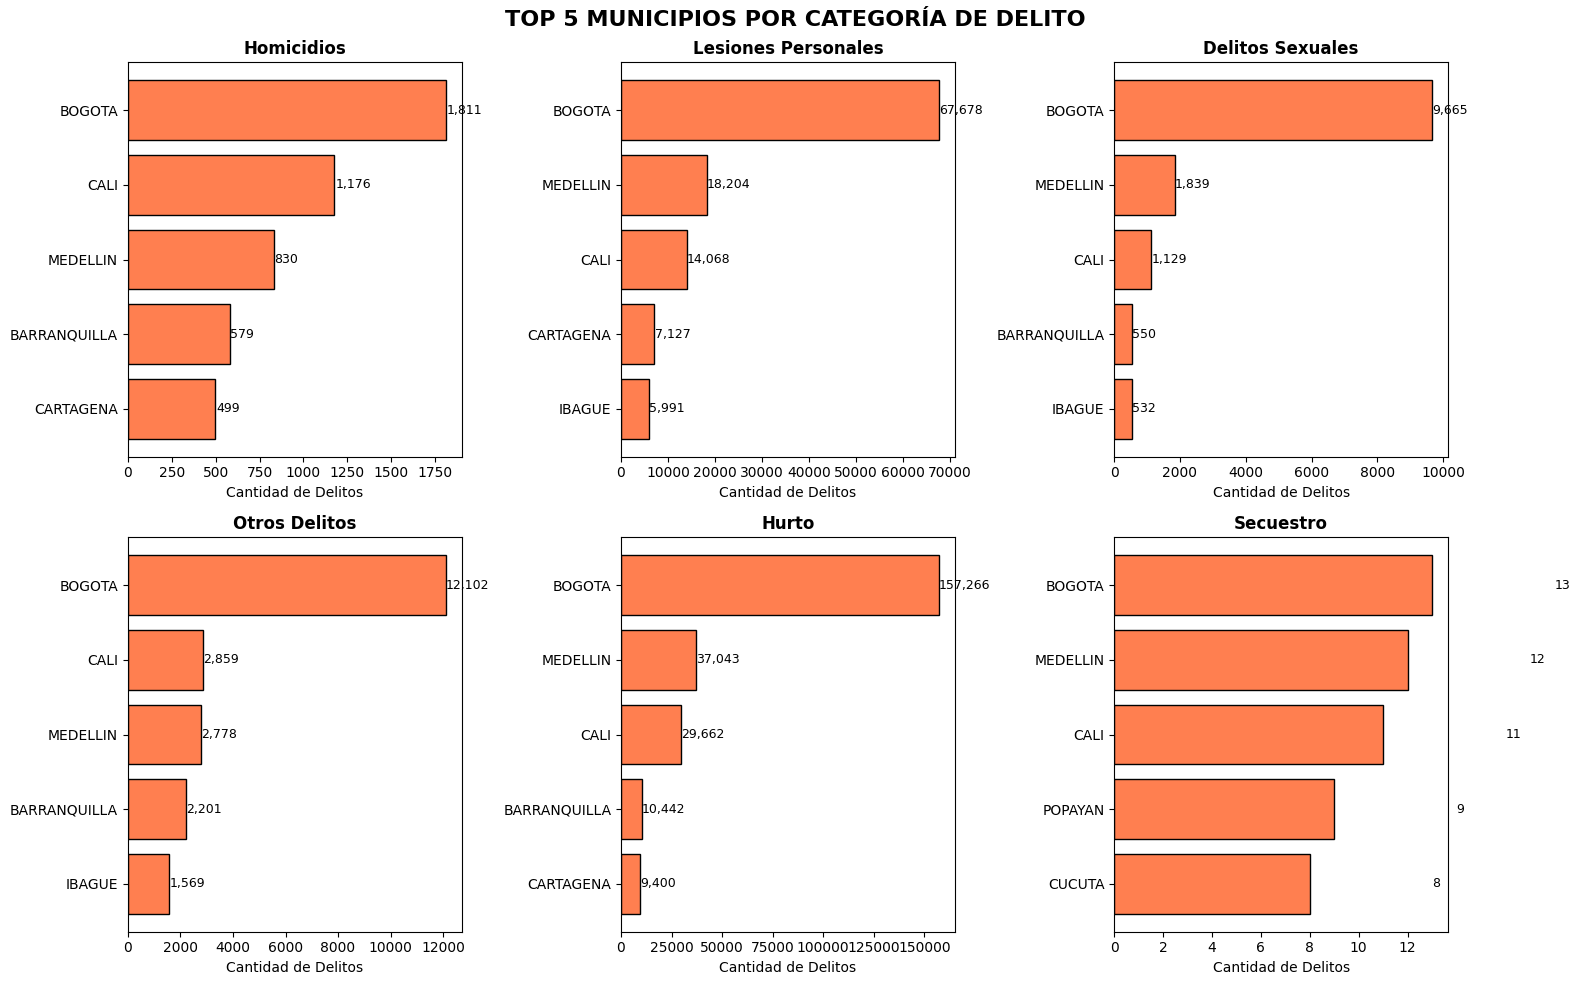

In [ ]:
import matplotlib.pyplot as plt

# Lista de categorías
categorias = df_delitos['CATEGORIA'].unique()

# Guardar datos
datos = {}

# Crear top 5 por categoría
for cat in categorias:

    top = (
        df_delitos[
            df_delitos['CATEGORIA'] == cat
        ]
        .groupby('MUNICIPIO')['CANTIDAD']
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    datos[cat] = {
        row['MUNICIPIO']: row['CANTIDAD']
        for _, row in top.iterrows()
    }

# Configurar gráficos
fig, axes = plt.subplots(2, 3, figsize=(16,10))

axes = axes.flatten()

# Crear cada gráfico
for i, cat in enumerate(categorias):

    municipios = list(datos[cat].keys())
    valores = list(datos[cat].values())

    bars = axes[i].barh(
        municipios,
        valores,
        color='coral',
        edgecolor='black'
    )

    axes[i].set_title(
        cat,
        fontsize=12,
        fontweight='bold'
    )

    axes[i].set_xlabel('Cantidad de Delitos')

    axes[i].invert_yaxis()

    # Agregar números
    for bar, val in zip(bars, valores):

        axes[i].text(
            val + 5,
            bar.get_y() + bar.get_height()/2,
            f'{int(val):,}',
            va='center',
            fontsize=9
        )

# Ocultar gráfico sobrante
if len(categorias) < 6:
    axes[-1].set_visible(False)

# Título general
plt.suptitle(
    'TOP 5 MUNICIPIOS POR CATEGORÍA DE DELITO',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

###  5.11.Top 10 municipios con mas delitos mapa de calor

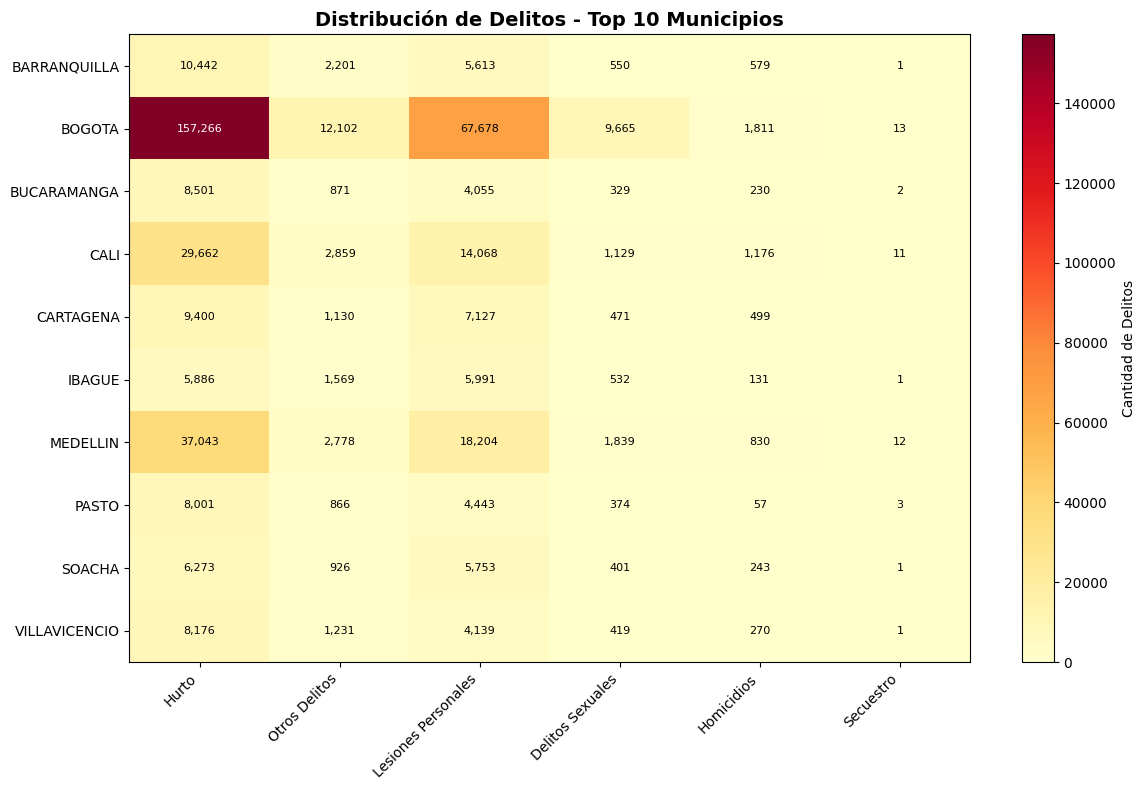

In [ ]:
# Top 10 municipios con más delitos totales
top10_municipios = (df_delitos.groupby('MUNICIPIO')['CANTIDAD']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar datos
top10_datos = df_delitos[df_delitos['MUNICIPIO'].isin(top10_municipios)]

# Pivotar correctamente
pivot_top10 = top10_datos.pivot_table(
    index='MUNICIPIO',
    columns='CATEGORIA',
    values='CANTIDAD',
    aggfunc='sum',
    fill_value=0
)

# Reordenar columnas
orden_cats = [
    'Hurto',
    'Otros Delitos',
    'Lesiones Personales',
    'Delitos Sexuales',
    'Homicidios',
    'Secuestro'
]

pivot_top10 = pivot_top10[orden_cats]

# Mapa de calor
fig, ax = plt.subplots(figsize=(12,8))

im = ax.imshow(
    pivot_top10.values,
    cmap='YlOrRd',
    aspect='auto'
)

# Configurar ejes
ax.set_xticks(range(len(pivot_top10.columns)))
ax.set_xticklabels(
    pivot_top10.columns,
    rotation=45,
    ha='right'
)

ax.set_yticks(range(len(pivot_top10.index)))
ax.set_yticklabels(pivot_top10.index)

ax.set_title(
    'Distribución de Delitos - Top 10 Municipios',
    fontsize=14,
    fontweight='bold'
)

# Valores dentro de celdas
for i in range(len(pivot_top10.index)):

    for j in range(len(pivot_top10.columns)):

        val = pivot_top10.values[i, j]

        if val > 0:

            text_color = (
                'white'
                if val > pivot_top10.values.max()/2
                else 'black'
            )

            ax.text(
                j,
                i,
                f'{int(val):,}',
                ha='center',
                va='center',
                color=text_color,
                fontsize=8
            )

plt.colorbar(im, ax=ax, label='Cantidad de Delitos')

plt.tight_layout()

plt.show()

##  6.Estadisticas de numero de suicidios por municipios

In [ ]:
# Suicidios por municipio (todos)
suicidios_por_municipio = df_suicidios_2024.groupby('Municipio del hecho DANE').size().reset_index(name='SUICIDIOS')
suicidios_por_municipio = suicidios_por_municipio.sort_values('SUICIDIOS', ascending=False)

print("="*60)
print("SUICIDIOS POR MUNICIPIO")
print("="*60)
print(f"Total de municipios: {len(suicidios_por_municipio)}")
print(f"Total de suicidios: {suicidios_por_municipio['SUICIDIOS'].sum()}")
print("\nLista completa:")
print(suicidios_por_municipio.to_string(index=False))

SUICIDIOS POR MUNICIPIO
Total de municipios: 609
Total de suicidios: 3008

Lista completa:
   Municipio del hecho DANE  SUICIDIOS
                     BOGOTA        363
                   MEDELLIN        194
                       CALI        131
                      PASTO         51
                     CUCUTA         50
                    PEREIRA         47
                      BELLO         45
              VILLAVICENCIO         43
                     IBAGUE         37
               BARRANQUILLA         36
                    POPAYAN         35
                SANTA MARTA         34
                  CARTAGENA         33
                BUCARAMANGA         33
                     SOACHA         32
                  MANIZALES         28
                 VALLEDUPAR         27
                      NEIVA         23
                  FLORENCIA         23
                    ARMENIA         22
                   MONTERIA         22
                    PALMIRA         21
            

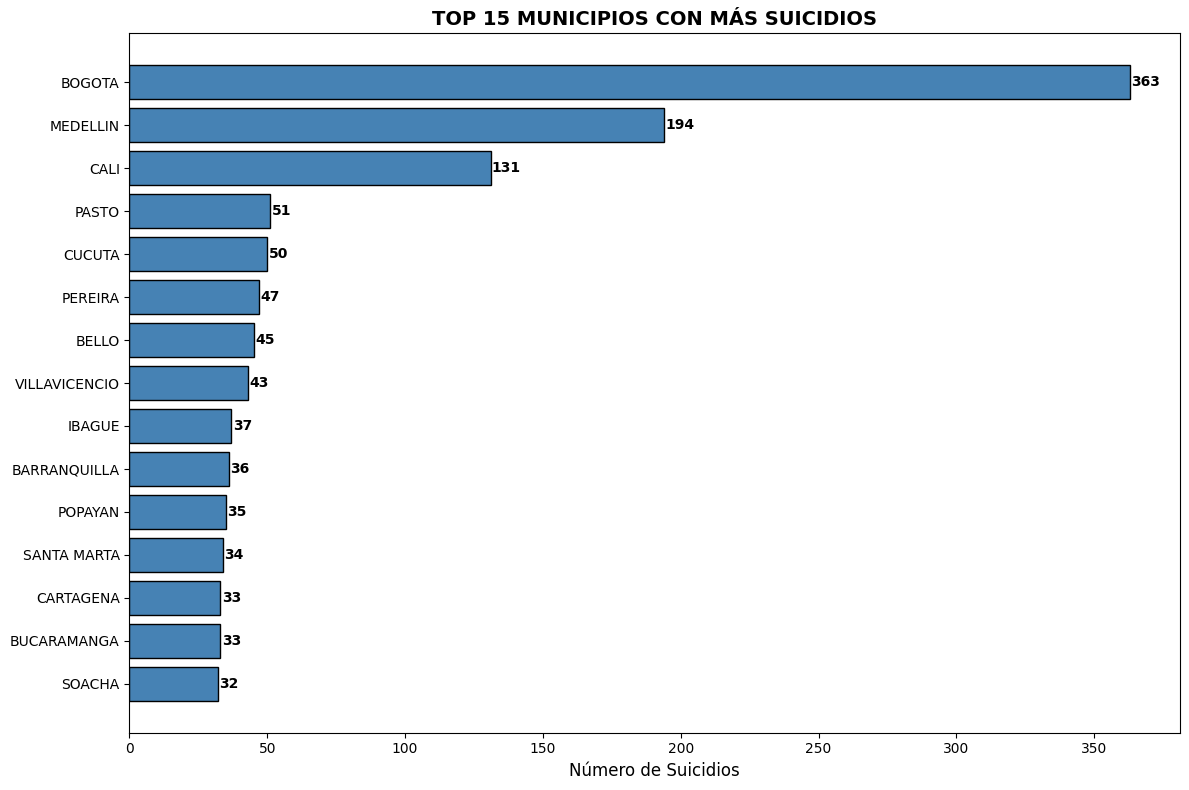

In [ ]:
import matplotlib.pyplot as plt

# Calcular suicidios por municipio
suicidios_por_municipio = df_suicidios_2024.groupby('Municipio del hecho DANE').size().reset_index(name='SUICIDIOS')
suicidios_por_municipio = suicidios_por_municipio.sort_values('SUICIDIOS', ascending=False)

# Top 15
top15 = suicidios_por_municipio.head(15)

# Gráfico de números
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top15)), top15['SUICIDIOS'], color='steelblue', edgecolor='black')
plt.yticks(range(len(top15)), top15['Municipio del hecho DANE'])
plt.xlabel('Número de Suicidios', fontsize=12)
plt.title('TOP 15 MUNICIPIOS CON MÁS SUICIDIOS', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Agregar valores en las barras
for i, (bar, val) in enumerate(zip(bars, top15['SUICIDIOS'])):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{int(val)}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

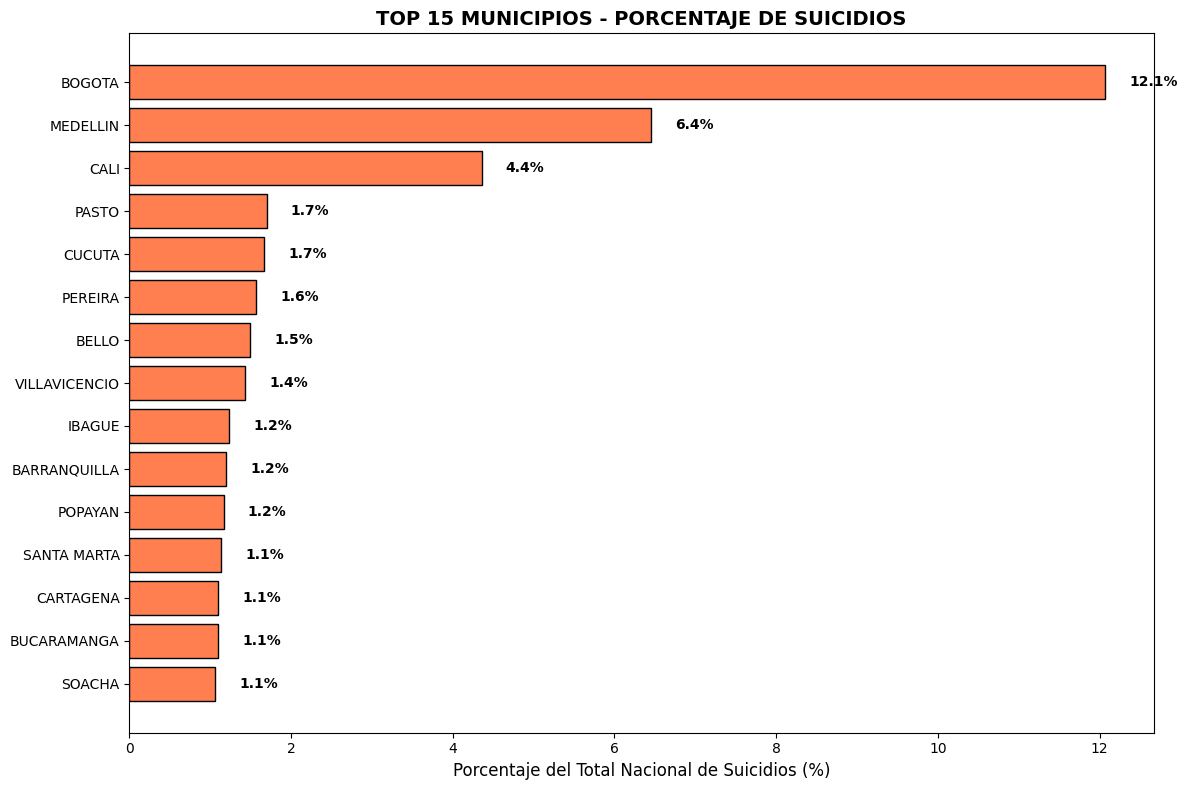

In [ ]:
# Calcular porcentaje
total_suicidios = suicidios_por_municipio['SUICIDIOS'].sum()
suicidios_por_municipio['PORCENTAJE'] = (suicidios_por_municipio['SUICIDIOS'] / total_suicidios) * 100

# Top 15
top15 = suicidios_por_municipio.head(15)

# Gráfico de porcentajes
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top15)), top15['PORCENTAJE'], color='coral', edgecolor='black')
plt.yticks(range(len(top15)), top15['Municipio del hecho DANE'])
plt.xlabel('Porcentaje del Total Nacional de Suicidios (%)', fontsize=12)
plt.title('TOP 15 MUNICIPIOS - PORCENTAJE DE SUICIDIOS', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Agregar valores en las barras
for i, (bar, val) in enumerate(zip(bars, top15['PORCENTAJE'])):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

##  7.Estadisticas generales de variables de la base de suicidios

###  7.1.edad

In [ ]:
import matplotlib.pyplot as plt

print("="*60)
print("ESTADÍSTICAS - GRUPO DE EDAD QUINQUENAL")
print("="*60)

edad_stats = df_suicidios_2024['Grupo de Edad Quinquenal '].value_counts()
edad_pct = (edad_stats / len(df_suicidios_2024)) * 100

edad_df = pd.DataFrame({
    'Cantidad': edad_stats,
    'Porcentaje (%)': edad_pct.round(1)
})
print(edad_df)



ESTADÍSTICAS - GRUPO DE EDAD QUINQUENAL
                           Cantidad  Porcentaje (%)
Grupo de Edad Quinquenal                           
(20 a 24)                       413            13.7
(25 a 29)                       377            12.5
(30 a 34)                       293             9.7
(35 a 39)                       278             9.2
(40 a 44)                       216             7.2
(55 a 59)                       181             6.0
(15 a 17)                       172             5.7
(45 a 49)                       167             5.6
(50 a 54)                       165             5.5
(60 a 64)                       158             5.3
(18 a 19)                       141             4.7
(65 a 69)                       138             4.6
(10 a 14)                       112             3.7
(70 a 74)                        95             3.2
(75 a 79)                        53             1.8
(80 y más)                       47             1.6
(05 a 09)               

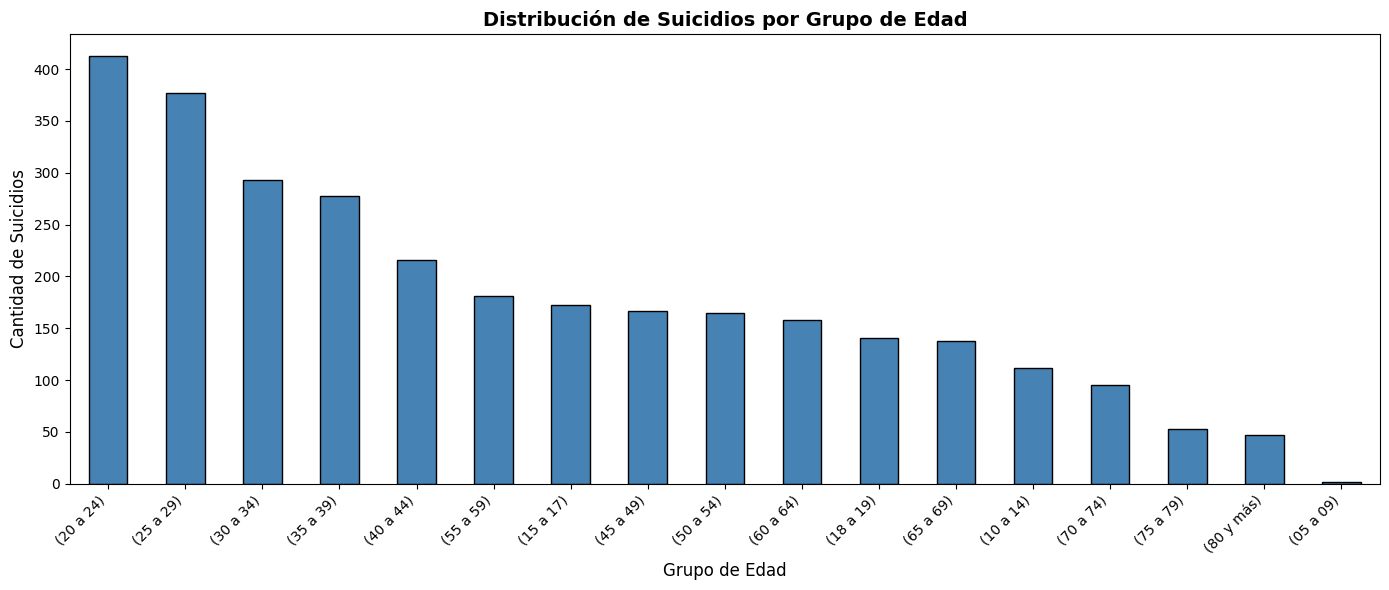

In [ ]:
# Gráfico
plt.figure(figsize=(14, 6))
edad_stats.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribución de Suicidios por Grupo de Edad', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Cantidad de Suicidios', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 7.2.Grupo Mayor o Menor de Edad

In [ ]:
print("="*60)
print("ESTADÍSTICAS - GRUPO MAYOR/MENOR DE EDAD")
print("="*60)

grupo_edad_stats = df_suicidios_2024['Grupo Mayor Menor de Edad'].value_counts()
grupo_edad_pct = (grupo_edad_stats / len(df_suicidios_2024)) * 100

grupo_df = pd.DataFrame({
    'Cantidad': grupo_edad_stats,
    'Porcentaje (%)': grupo_edad_pct.round(1)
})
print(grupo_df)



ESTADÍSTICAS - GRUPO MAYOR/MENOR DE EDAD
                               Cantidad  Porcentaje (%)
Grupo Mayor Menor de Edad                              
b) Mayores de Edad (>18 años)      2722            90.5
a) Menores de Edad (<18 años)       286             9.5


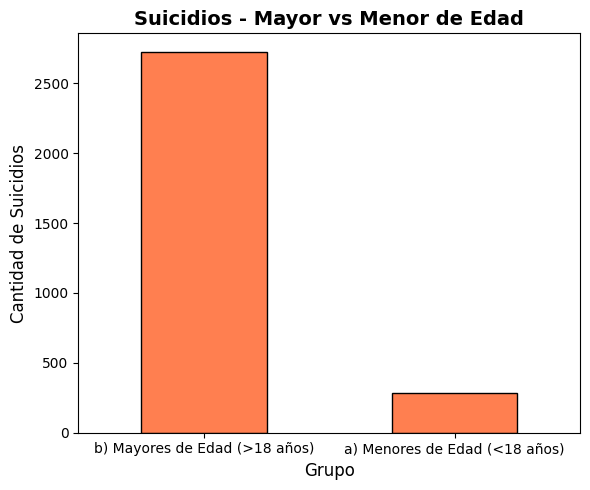

In [ ]:
# Gráfico
plt.figure(figsize=(6, 5))
grupo_edad_stats.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Suicidios - Mayor vs Menor de Edad', fontsize=14, fontweight='bold')
plt.xlabel('Grupo', fontsize=12)
plt.ylabel('Cantidad de Suicidios', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 7.3.Sexo de la Víctima

In [ ]:
print("="*60)
print(" ESTADÍSTICAS - SEXO DE LA VÍCTIMA")
print("="*60)

sexo_stats = df_suicidios_2024['Sexo de la victima'].value_counts()
sexo_pct = (sexo_stats / len(df_suicidios_2024)) * 100

sexo_df = pd.DataFrame({
    'Cantidad': sexo_stats,
    'Porcentaje (%)': sexo_pct.round(1)
})
print(sexo_df)



 ESTADÍSTICAS - SEXO DE LA VÍCTIMA
                    Cantidad  Porcentaje (%)
Sexo de la victima                          
Hombre                  2418            80.4
Mujer                    590            19.6


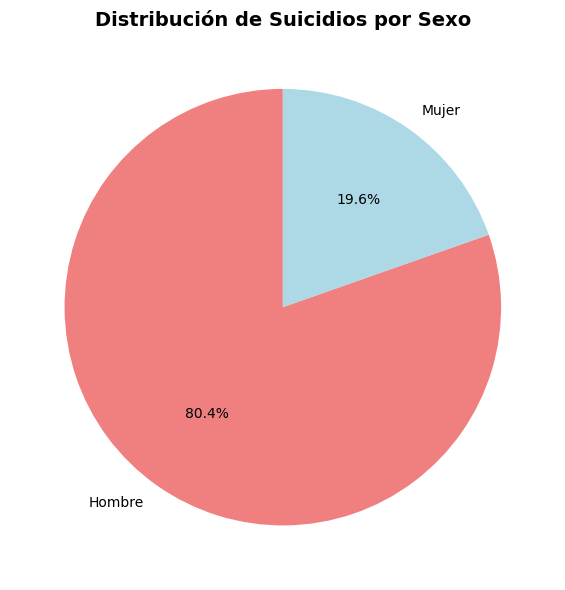

In [ ]:
# Gráfico
plt.figure(figsize=(6, 6))
plt.pie(sexo_stats, labels=sexo_stats.index, autopct='%1.1f%%', startangle=90,
        colors=['lightcoral', 'lightblue'])
plt.title('Distribución de Suicidios por Sexo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###  7.4.Estado Civil

In [ ]:
print("="*60)
print("ESTADÍSTICAS - ESTADO CIVIL")
print("="*60)

civil_stats = df_suicidios_2024['Estado Civil'].value_counts()
civil_pct = (civil_stats / len(df_suicidios_2024)) * 100

civil_df = pd.DataFrame({
    'Cantidad': civil_stats,
    'Porcentaje (%)': civil_pct.round(1)
})
print(civil_df)


ESTADÍSTICAS - ESTADO CIVIL
                            Cantidad  Porcentaje (%)
Estado Civil                                        
Soltero(a)                      1431            47.6
Unión libre                      709            23.6
Sin información                  385            12.8
Casado(a)                        324            10.8
Separado(a), divorciado(a)       107             3.6
Viudo(a)                          50             1.7
No aplica                          2             0.1


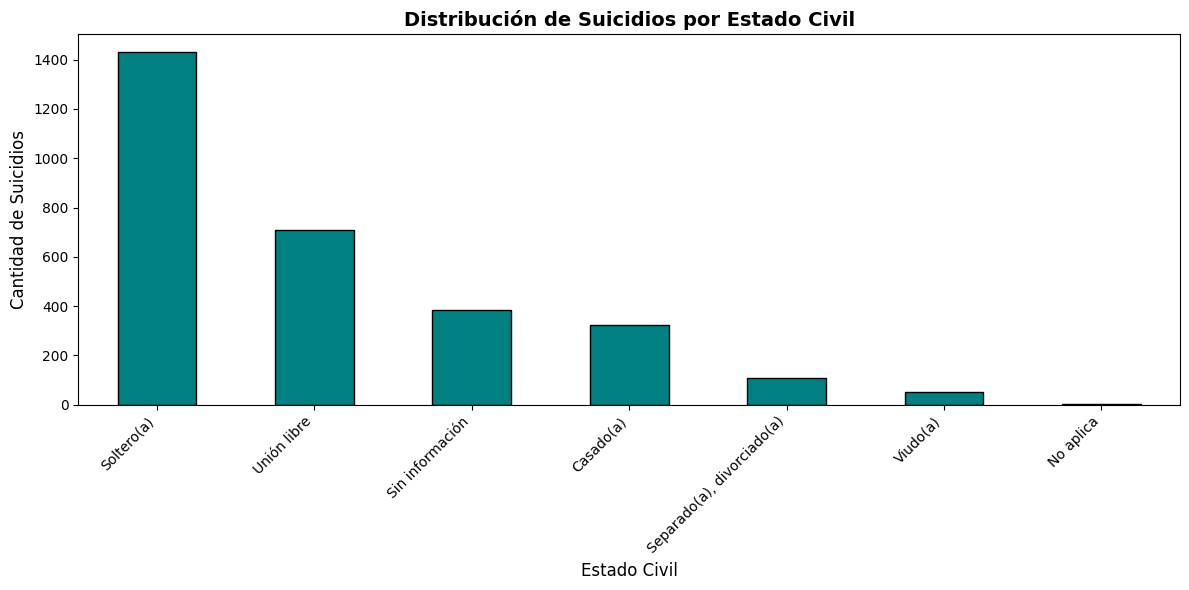

In [ ]:
# Gráfico
plt.figure(figsize=(12, 6))
civil_stats.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Distribución de Suicidios por Estado Civil', fontsize=14, fontweight='bold')
plt.xlabel('Estado Civil', fontsize=12)
plt.ylabel('Cantidad de Suicidios', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###  7.5.País de Nacimiento

In [ ]:
print("="*60)
print("ESTADÍSTICAS - PAÍS DE NACIMIENTO")
print("="*60)

pais_stats = df_suicidios_2024['País de Nacimiento'].value_counts()
pais_pct = (pais_stats / len(df_suicidios_2024)) * 100

pais_df = pd.DataFrame({
    'Cantidad': pais_stats,
    'Porcentaje (%)': pais_pct.round(1)
})
print(pais_df.head(10))

ESTADÍSTICAS - PAÍS DE NACIMIENTO
                    Cantidad  Porcentaje (%)
País de Nacimiento                          
Colombia                2914            96.9
Venezuela                 71             2.4
Estados Unidos             3             0.1
Sin información            3             0.1
España                     2             0.1
Alemania                   2             0.1
Argentina                  2             0.1
Ecuador                    2             0.1
Filipinas                  1             0.0
Lituania                   1             0.0


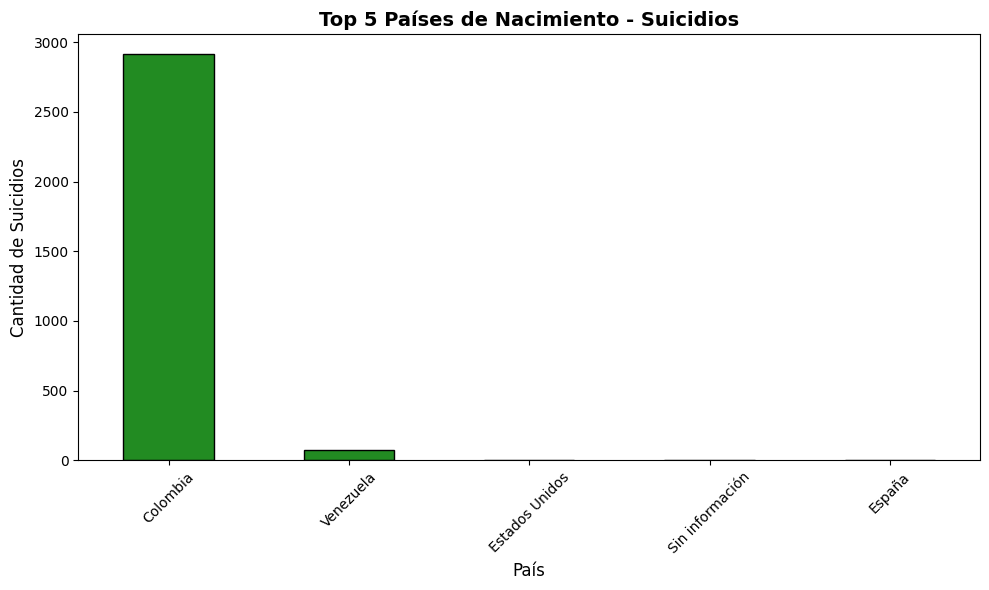

In [ ]:
# Gráfico (top 5)
plt.figure(figsize=(10, 6))
pais_stats.head(5).plot(kind='bar', color='forestgreen', edgecolor='black')
plt.title('Top 5 Países de Nacimiento - Suicidios', fontsize=14, fontweight='bold')
plt.xlabel('País', fontsize=12)
plt.ylabel('Cantidad de Suicidios', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###  7.6.Escenario del Hecho

In [ ]:
print("="*60)
print("ESTADÍSTICAS - ESCENARIO DEL HECHO")
print("="*60)

escenario_stats = df_suicidios_2024['Escenario del Hecho'].value_counts()
escenario_pct = (escenario_stats / len(df_suicidios_2024)) * 100

escenario_df = pd.DataFrame({
    'Cantidad': escenario_stats,
    'Porcentaje (%)': escenario_pct.round(1)
})
print(escenario_df.head(10))


ESTADÍSTICAS - ESCENARIO DEL HECHO
                                                    Cantidad  Porcentaje (%)
Escenario del Hecho                                                         
Vivienda                                                2197            73.0
Vía pública                                              151             5.0
Zonas de actividades agropecuarias                       141             4.7
Espacios terrestres al aire libre (bosque, potr...       118             3.9
Otros                                                     94             3.1
Sin información                                           80             2.7
Lugares de hospedaje (hoteles, campamentos y ot...        50             1.7
Guarniciones militares y/o de policía                     23             0.8
Centros de reclusión                                      20             0.7
Espacios acuáticos al aire libre (mar, río, arr...        20             0.7


/tmp/ipykernel_1554/613273142.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


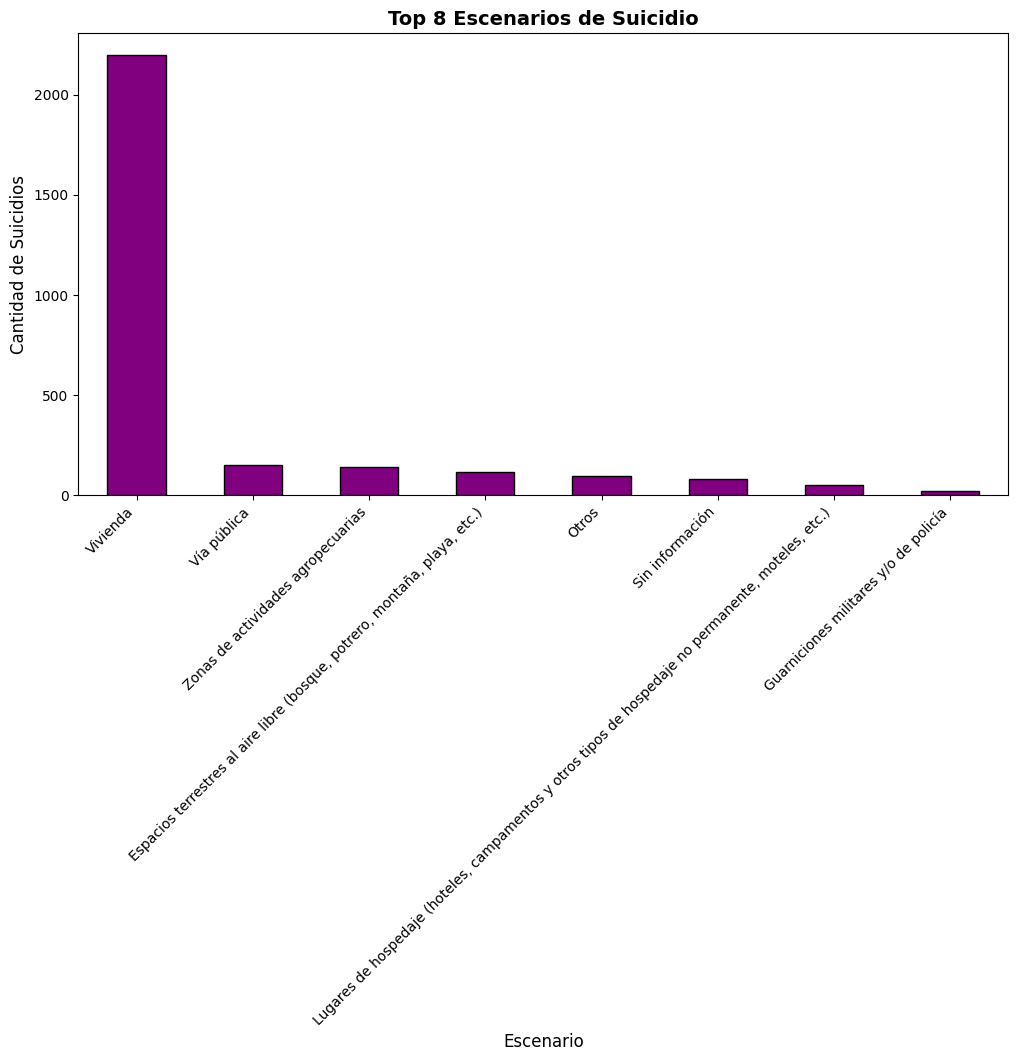

In [ ]:
# Gráfico
plt.figure(figsize=(12, 6))
escenario_stats.head(8).plot(kind='bar', color='purple', edgecolor='black')
plt.title('Top 8 Escenarios de Suicidio', fontsize=14, fontweight='bold')
plt.xlabel('Escenario', fontsize=12)
plt.ylabel('Cantidad de Suicidios', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 7.7.Mecanismo Causal de la Lesión Fatal

In [ ]:
print("="*60)
print(" ESTADÍSTICAS - MECANISMO CAUSAL")
print("="*60)

mecanismo_stats = df_suicidios_2024['Mecanismo Causal de la Lesión Fatal'].value_counts()
mecanismo_pct = (mecanismo_stats / len(df_suicidios_2024)) * 100

mecanismo_df = pd.DataFrame({
    'Cantidad': mecanismo_stats,
    'Porcentaje (%)': mecanismo_pct.round(1)
})
print(mecanismo_df)


 ESTADÍSTICAS - MECANISMO CAUSAL
                                     Cantidad  Porcentaje (%)
Mecanismo Causal de la Lesión Fatal                          
Generadores de asfixia                   2123            70.6
Tóxico                                    387            12.9
Proyectil de arma de fuego                248             8.2
Contundente                               189             6.3
Cortopunzante                              30             1.0
Cortante                                   17             0.6
Térmico                                    13             0.4
Cortocontundente                            1             0.0


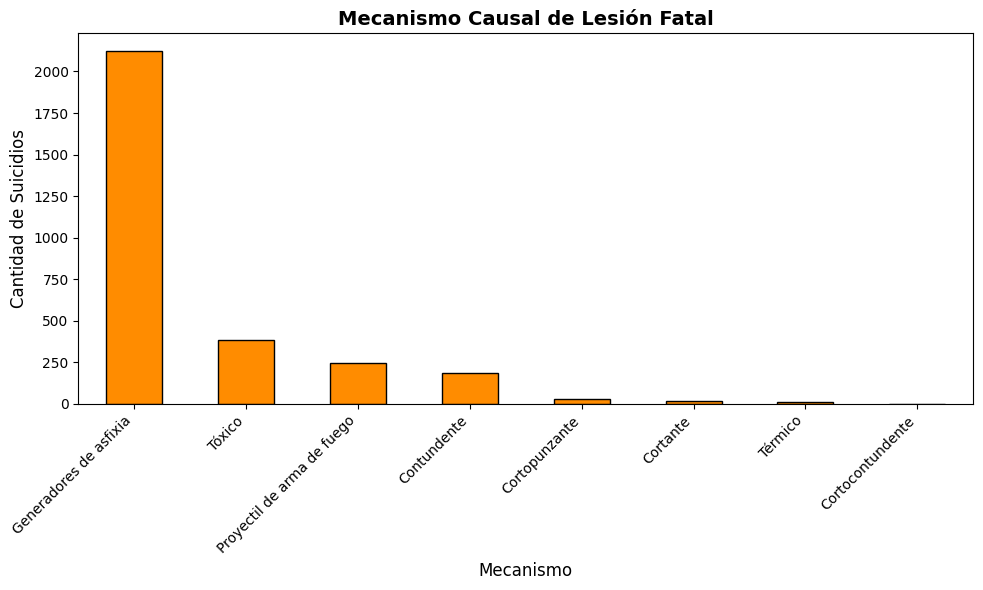

In [ ]:
# Gráfico
plt.figure(figsize=(10, 6))
mecanismo_stats.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Mecanismo Causal de Lesión Fatal', fontsize=14, fontweight='bold')
plt.xlabel('Mecanismo', fontsize=12)
plt.ylabel('Cantidad de Suicidios', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##  8.Estadisticas generales de las variables en relacion con los municipio

### 8.1.edad

In [ ]:
# Edad por municipio - top 5 municipios con más suicidios
top_municipios = df_suicidios_2024['Municipio del hecho DANE'].value_counts().head(5).index

for municipio in top_municipios:
    print(f"\n{'='*60}")
    print(f" {municipio} - GRUPO DE EDAD")
    print('='*60)
    datos_mun = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'] == municipio]
    edad_stats = datos_mun['Grupo de Edad Quinquenal '].value_counts()
    edad_pct = (edad_stats / len(datos_mun)) * 100
    edad_df = pd.DataFrame({'Cantidad': edad_stats, 'Porcentaje (%)': edad_pct.round(1)})
    print(edad_df)


 BOGOTA - GRUPO DE EDAD
                           Cantidad  Porcentaje (%)
Grupo de Edad Quinquenal                           
(25 a 29)                        55            15.2
(20 a 24)                        54            14.9
(30 a 34)                        46            12.7
(40 a 44)                        36             9.9
(35 a 39)                        29             8.0
(15 a 17)                        21             5.8
(50 a 54)                        19             5.2
(18 a 19)                        18             5.0
(45 a 49)                        17             4.7
(55 a 59)                        17             4.7
(65 a 69)                        13             3.6
(60 a 64)                        11             3.0
(10 a 14)                        10             2.8
(70 a 74)                         9             2.5
(75 a 79)                         5             1.4
(80 y más)                        3             0.8

 MEDELLIN - GRUPO DE EDAD
            

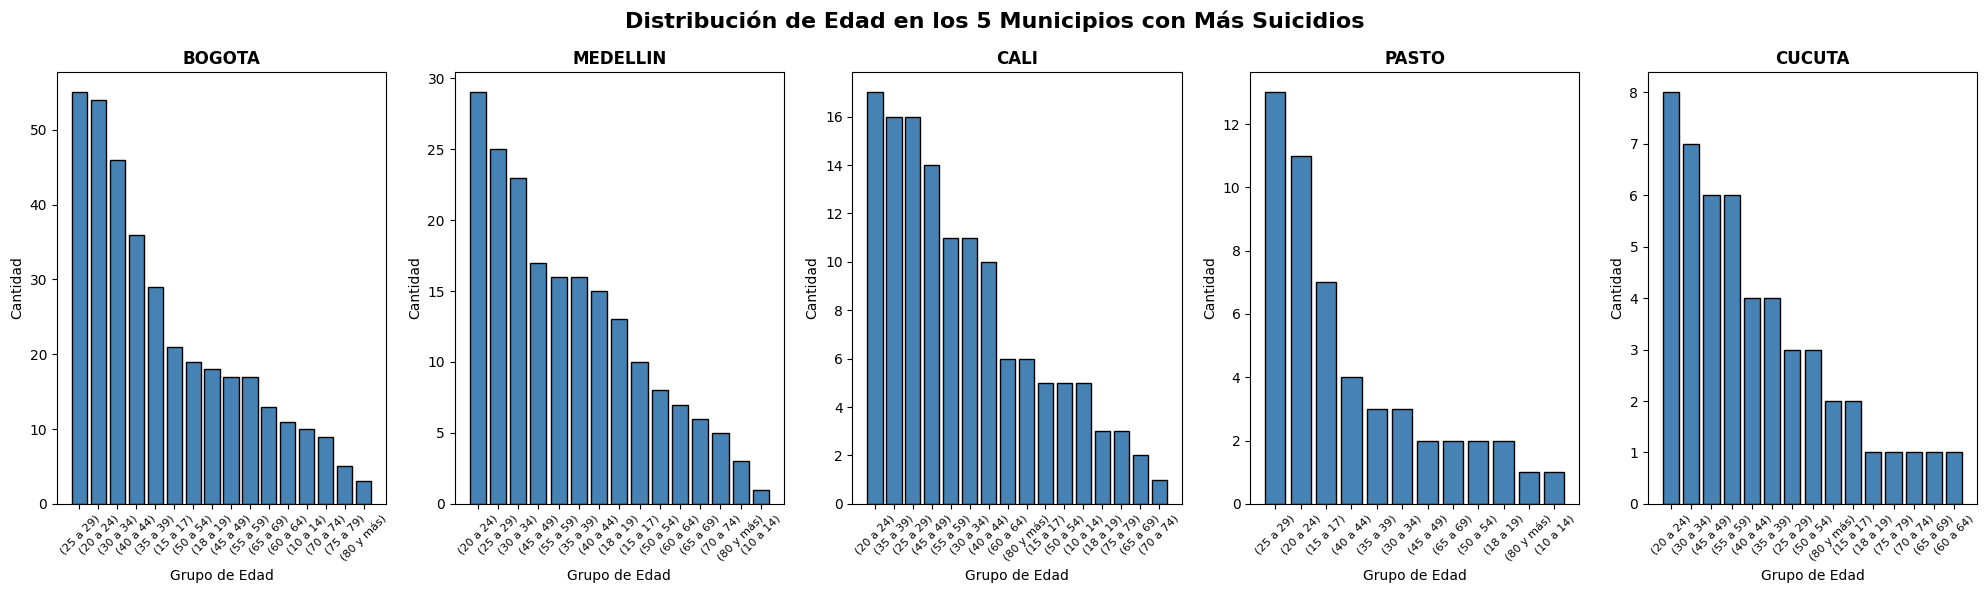

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Top 5 municipios con más suicidios
top5_municipios = df_suicidios_2024['Municipio del hecho DANE'].value_counts().head(5).index

# Gráfico de edad por municipio
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle('Distribución de Edad en los 5 Municipios con Más Suicidios', fontsize=16, fontweight='bold')

for i, municipio in enumerate(top5_municipios):
    datos_mun = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'] == municipio]
    edad_stats = datos_mun['Grupo de Edad Quinquenal '].value_counts()

    axes[i].bar(edad_stats.index, edad_stats.values, color='steelblue', edgecolor='black')
    axes[i].set_title(municipio, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Grupo de Edad')
    axes[i].set_ylabel('Cantidad')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

### 8.2.Grupo Mayor o Menor de Edad

In [ ]:
for municipio in top_municipios:
    print(f"\n{'='*60}")
    print(f" {municipio} - MAYOR/MENOR DE EDAD")
    print('='*60)
    datos_mun = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'] == municipio]
    grupo_stats = datos_mun['Grupo Mayor Menor de Edad'].value_counts()
    grupo_pct = (grupo_stats / len(datos_mun)) * 100
    grupo_df = pd.DataFrame({'Cantidad': grupo_stats, 'Porcentaje (%)': grupo_pct.round(1)})
    print(grupo_df)


 BOGOTA - MAYOR/MENOR DE EDAD
                               Cantidad  Porcentaje (%)
Grupo Mayor Menor de Edad                              
b) Mayores de Edad (>18 años)       332            91.5
a) Menores de Edad (<18 años)        31             8.5

 MEDELLIN - MAYOR/MENOR DE EDAD
                               Cantidad  Porcentaje (%)
Grupo Mayor Menor de Edad                              
b) Mayores de Edad (>18 años)       183            94.3
a) Menores de Edad (<18 años)        11             5.7

 CALI - MAYOR/MENOR DE EDAD
                               Cantidad  Porcentaje (%)
Grupo Mayor Menor de Edad                              
b) Mayores de Edad (>18 años)       121            92.4
a) Menores de Edad (<18 años)        10             7.6

 PASTO - MAYOR/MENOR DE EDAD
                               Cantidad  Porcentaje (%)
Grupo Mayor Menor de Edad                              
b) Mayores de Edad (>18 años)        43            84.3
a) Menores de Edad (<18 años)        

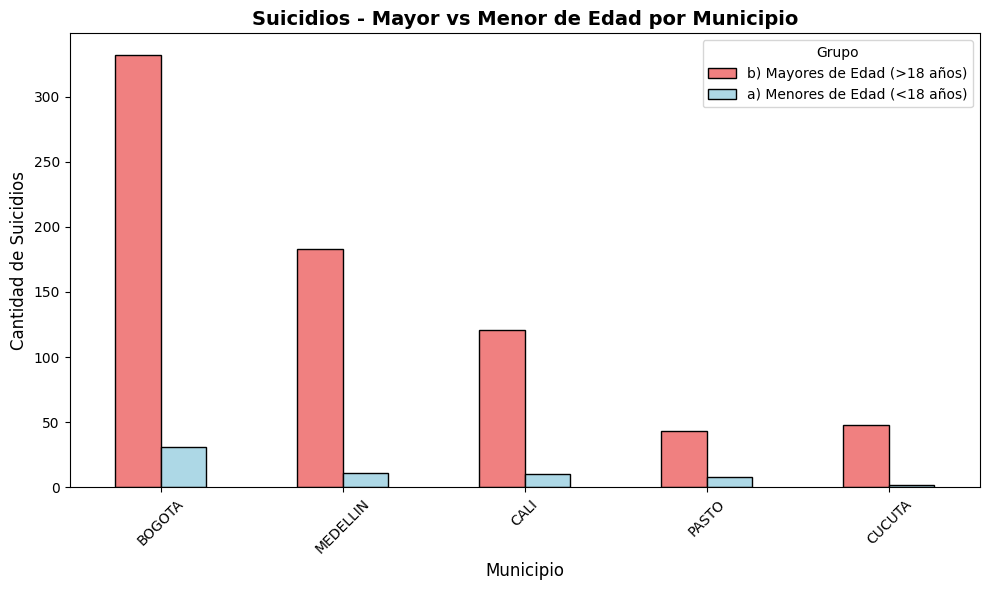

In [ ]:
# Preparar datos
mayor_menor_por_muni = pd.DataFrame()
for municipio in top5_municipios:
    datos_mun = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'] == municipio]
    grupo_stats = datos_mun['Grupo Mayor Menor de Edad'].value_counts()
    mayor_menor_por_muni[municipio] = grupo_stats

mayor_menor_por_muni = mayor_menor_por_muni.fillna(0)

# Gráfico
mayor_menor_por_muni.T.plot(kind='bar', figsize=(10, 6), color=['lightcoral', 'lightblue'], edgecolor='black')
plt.title('Suicidios - Mayor vs Menor de Edad por Municipio', fontsize=14, fontweight='bold')
plt.xlabel('Municipio', fontsize=12)
plt.ylabel('Cantidad de Suicidios', fontsize=12)
plt.legend(title='Grupo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 8.3.Sexo de la Víctima

In [ ]:
for municipio in top_municipios:
    print(f"\n{'='*60}")
    print(f" {municipio} - SEXO DE LA VÍCTIMA")
    print('='*60)
    datos_mun = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'] == municipio]
    sexo_stats = datos_mun['Sexo de la victima'].value_counts()
    sexo_pct = (sexo_stats / len(datos_mun)) * 100
    sexo_df = pd.DataFrame({'Cantidad': sexo_stats, 'Porcentaje (%)': sexo_pct.round(1)})
    print(sexo_df)


 BOGOTA - SEXO DE LA VÍCTIMA
                    Cantidad  Porcentaje (%)
Sexo de la victima                          
Hombre                   281            77.4
Mujer                     82            22.6

 MEDELLIN - SEXO DE LA VÍCTIMA
                    Cantidad  Porcentaje (%)
Sexo de la victima                          
Hombre                   152            78.4
Mujer                     42            21.6

 CALI - SEXO DE LA VÍCTIMA
                    Cantidad  Porcentaje (%)
Sexo de la victima                          
Hombre                   106            80.9
Mujer                     25            19.1

 PASTO - SEXO DE LA VÍCTIMA
                    Cantidad  Porcentaje (%)
Sexo de la victima                          
Hombre                    32            62.7
Mujer                     19            37.3

 CUCUTA - SEXO DE LA VÍCTIMA
                    Cantidad  Porcentaje (%)
Sexo de la victima                          
Hombre                    38            7

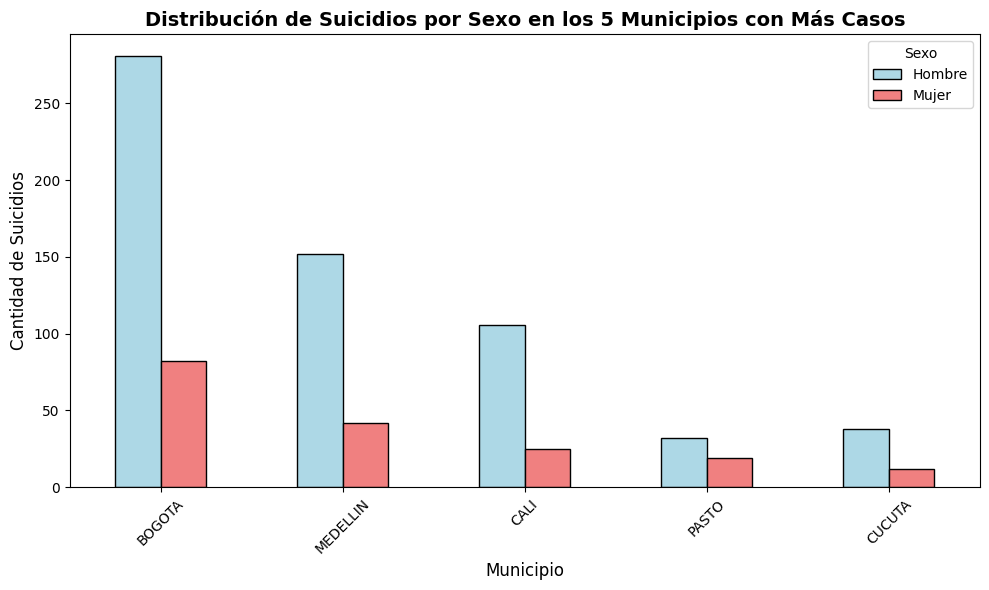

In [ ]:
# Preparar datos
sexo_por_muni = pd.DataFrame()
for municipio in top5_municipios:
    datos_mun = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'] == municipio]
    sexo_stats = datos_mun['Sexo de la victima'].value_counts()
    sexo_por_muni[municipio] = sexo_stats

sexo_por_muni = sexo_por_muni.fillna(0)

# Gráfico
sexo_por_muni.T.plot(kind='bar', figsize=(10, 6), color=['lightblue', 'lightcoral'], edgecolor='black')
plt.title('Distribución de Suicidios por Sexo en los 5 Municipios con Más Casos', fontsize=14, fontweight='bold')
plt.xlabel('Municipio', fontsize=12)
plt.ylabel('Cantidad de Suicidios', fontsize=12)
plt.legend(title='Sexo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###  7.4.Estado Civil

In [ ]:
for municipio in top_municipios:
    print(f"\n{'='*60}")
    print(f" {municipio} - ESTADO CIVIL")
    print('='*60)
    datos_mun = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'] == municipio]
    civil_stats = datos_mun['Estado Civil'].value_counts()
    civil_pct = (civil_stats / len(datos_mun)) * 100
    civil_df = pd.DataFrame({'Cantidad': civil_stats, 'Porcentaje (%)': civil_pct.round(1)})
    print(civil_df)


 BOGOTA - ESTADO CIVIL
                            Cantidad  Porcentaje (%)
Estado Civil                                        
Soltero(a)                       222            61.2
Unión libre                       82            22.6
Casado(a)                         31             8.5
Sin información                   11             3.0
Separado(a), divorciado(a)        11             3.0
Viudo(a)                           6             1.7

 MEDELLIN - ESTADO CIVIL
                            Cantidad  Porcentaje (%)
Estado Civil                                        
Soltero(a)                       119            61.3
Casado(a)                         31            16.0
Unión libre                       30            15.5
Separado(a), divorciado(a)        10             5.2
Sin información                    3             1.5
Viudo(a)                           1             0.5

 CALI - ESTADO CIVIL
                            Cantidad  Porcentaje (%)
Estado Civil               

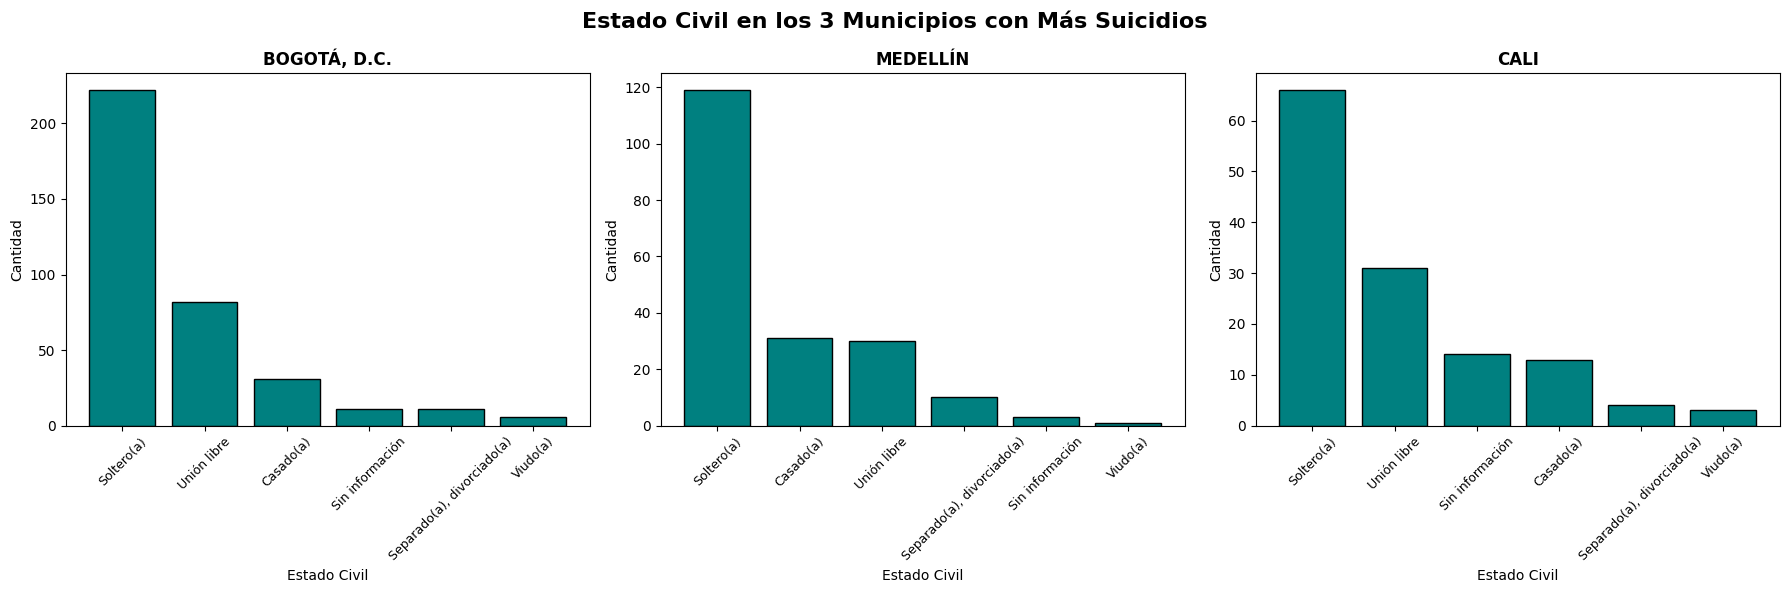

In [ ]:
# Top 3 municipios para mejor visualización
top3_municipios = top5_municipios[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Estado Civil en los 3 Municipios con Más Suicidios', fontsize=16, fontweight='bold')

for i, municipio in enumerate(top3_municipios):
    datos_mun = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'] == municipio]
    civil_stats = datos_mun['Estado Civil'].value_counts().head(6)

    axes[i].bar(civil_stats.index, civil_stats.values, color='teal', edgecolor='black')
    axes[i].set_title(municipio, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Estado Civil')
    axes[i].set_ylabel('Cantidad')
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)

plt.tight_layout()
plt.show()

###  8.5.País de Nacimiento

In [ ]:
for municipio in top_municipios:
    print(f"\n{'='*60}")
    print(f" {municipio} - PAÍS DE NACIMIENTO")
    print('='*60)
    datos_mun = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'] == municipio]
    pais_stats = datos_mun['País de Nacimiento'].value_counts().head(5)
    pais_pct = (pais_stats / len(datos_mun)) * 100
    pais_df = pd.DataFrame({'Cantidad': pais_stats, 'Porcentaje (%)': pais_pct.round(1)})
    print(pais_df)


 BOGOTÁ, D.C. - PAÍS DE NACIMIENTO
                    Cantidad  Porcentaje (%)
País de Nacimiento                          
Colombia                 351            96.7
Venezuela                  7             1.9
España                     1             0.3
Brasil                     1             0.3
Filipinas                  1             0.3

 MEDELLÍN - PAÍS DE NACIMIENTO
                    Cantidad  Porcentaje (%)
País de Nacimiento                          
Colombia                 180            92.8
Venezuela                  8             4.1
Estados Unidos             2             1.0
Lituania                   1             0.5
Alemania                   1             0.5

 CALI - PAÍS DE NACIMIENTO
                    Cantidad  Porcentaje (%)
País de Nacimiento                          
Colombia                 123            93.9
Venezuela                  6             4.6
Ecuador                    1             0.8
España                     1             0.8

 PA

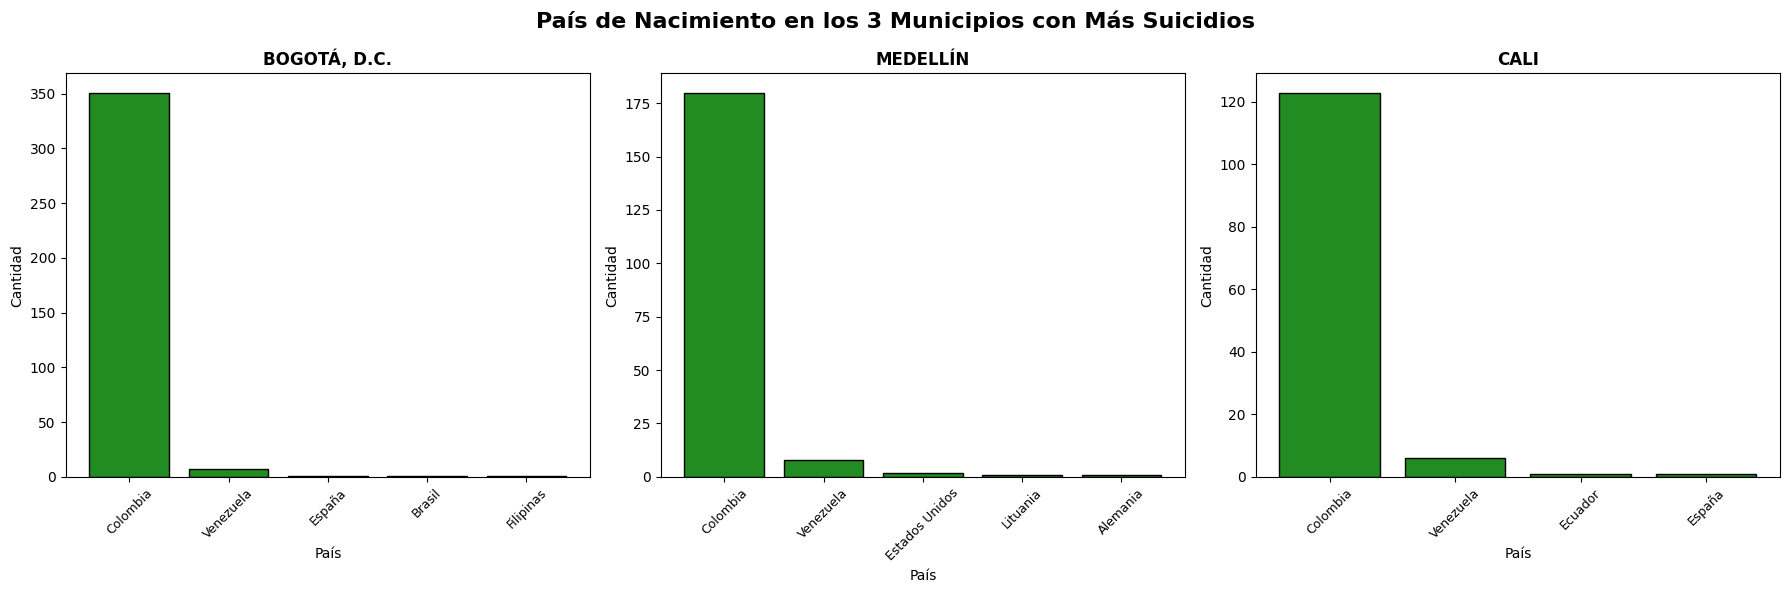

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('País de Nacimiento en los 3 Municipios con Más Suicidios', fontsize=16, fontweight='bold')

for i, municipio in enumerate(top3_municipios):
    datos_mun = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'] == municipio]
    pais_stats = datos_mun['País de Nacimiento'].value_counts().head(5)

    axes[i].bar(pais_stats.index, pais_stats.values, color='forestgreen', edgecolor='black')
    axes[i].set_title(municipio, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('País')
    axes[i].set_ylabel('Cantidad')
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)

plt.tight_layout()
plt.show()

###  8.6.Escenario del Hecho

In [ ]:
for municipio in top_municipios:
    print(f"\n{'='*60}")
    print(f" {municipio} - ESCENARIO DEL HECHO")
    print('='*60)
    datos_mun = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'] == municipio]
    escenario_stats = datos_mun['Escenario del Hecho'].value_counts().head(5)
    escenario_pct = (escenario_stats / len(datos_mun)) * 100
    escenario_df = pd.DataFrame({'Cantidad': escenario_stats, 'Porcentaje (%)': escenario_pct.round(1)})
    print(escenario_df)


 BOGOTÁ, D.C. - ESCENARIO DEL HECHO
                                                    Cantidad  Porcentaje (%)
Escenario del Hecho                                                         
Vivienda                                                 279            76.9
Vía pública                                               25             6.9
Otros                                                     12             3.3
Espacios terrestres al aire libre (bosque, potr...        10             2.8
Sin información                                            8             2.2

 MEDELLÍN - ESCENARIO DEL HECHO
                                                    Cantidad  Porcentaje (%)
Escenario del Hecho                                                         
Vivienda                                                 155            79.9
Vía pública                                               16             8.2
Otros                                                      9             4.6
Espaci

### 8.7.Mecanismo Causal de la Lesión Fatal

In [ ]:
for municipio in top_municipios:
    print(f"\n{'='*60}")
    print(f" {municipio} - MECANISMO CAUSAL")
    print('='*60)
    datos_mun = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'] == municipio]
    mecanismo_stats = datos_mun['Mecanismo Causal de la Lesión Fatal'].value_counts()
    mecanismo_pct = (mecanismo_stats / len(datos_mun)) * 100
    mecanismo_df = pd.DataFrame({'Cantidad': mecanismo_stats, 'Porcentaje (%)': mecanismo_pct.round(1)})
    print(mecanismo_df)


 BOGOTÁ, D.C. - MECANISMO CAUSAL
                                     Cantidad  Porcentaje (%)
Mecanismo Causal de la Lesión Fatal                          
Generadores de asfixia                    258            71.1
Contundente                                41            11.3
Tóxico                                     36             9.9
Proyectil de arma de fuego                 22             6.1
Cortopunzante                               4             1.1
Térmico                                     1             0.3
Cortocontundente                            1             0.3

 MEDELLÍN - MECANISMO CAUSAL
                                     Cantidad  Porcentaje (%)
Mecanismo Causal de la Lesión Fatal                          
Generadores de asfixia                    126            64.9
Contundente                                36            18.6
Tóxico                                     17             8.8
Proyectil de arma de fuego                 11             5.7
Cortop

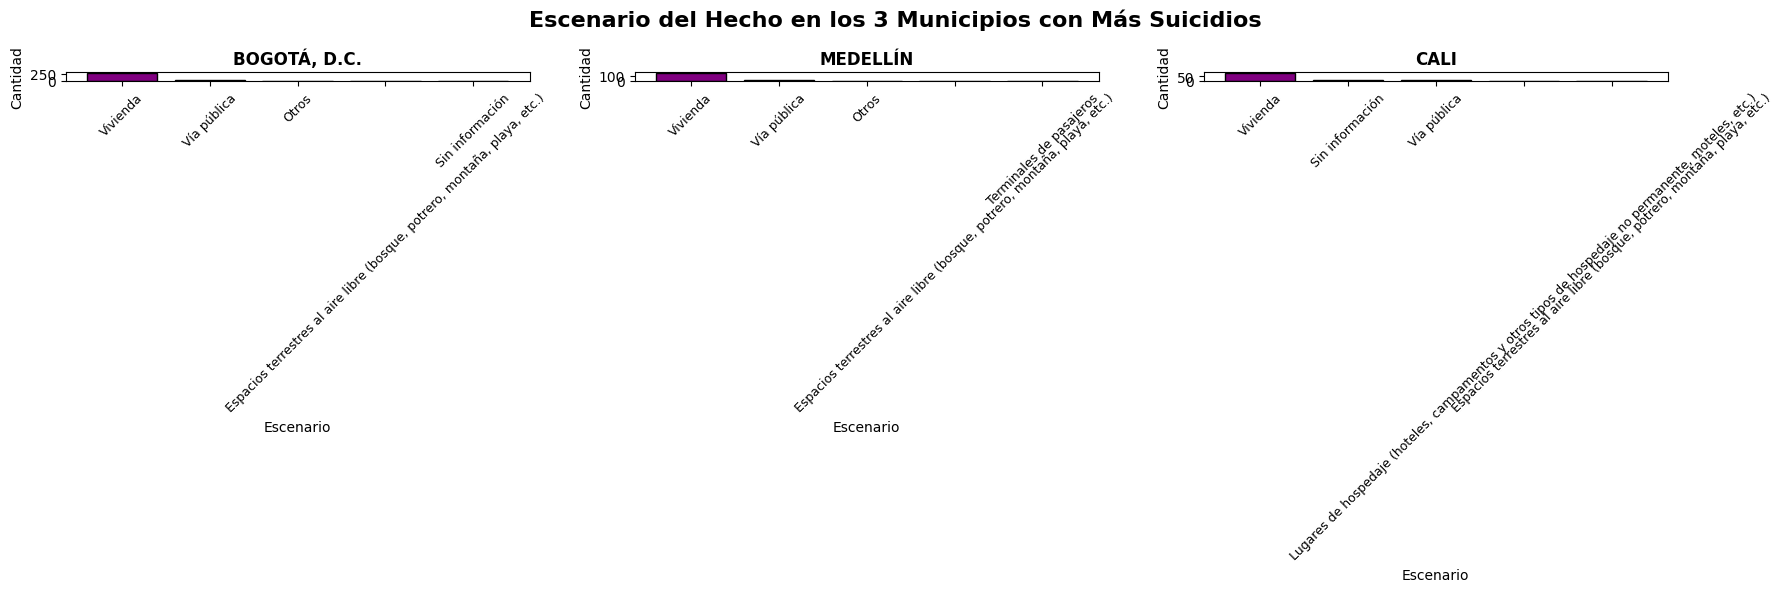

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Escenario del Hecho en los 3 Municipios con Más Suicidios', fontsize=16, fontweight='bold')

for i, municipio in enumerate(top3_municipios):
    datos_mun = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'] == municipio]
    escenario_stats = datos_mun['Escenario del Hecho'].value_counts().head(5)

    axes[i].bar(escenario_stats.index, escenario_stats.values, color='purple', edgecolor='black')
    axes[i].set_title(municipio, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Escenario')
    axes[i].set_ylabel('Cantidad')
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)

plt.tight_layout()
plt.show()

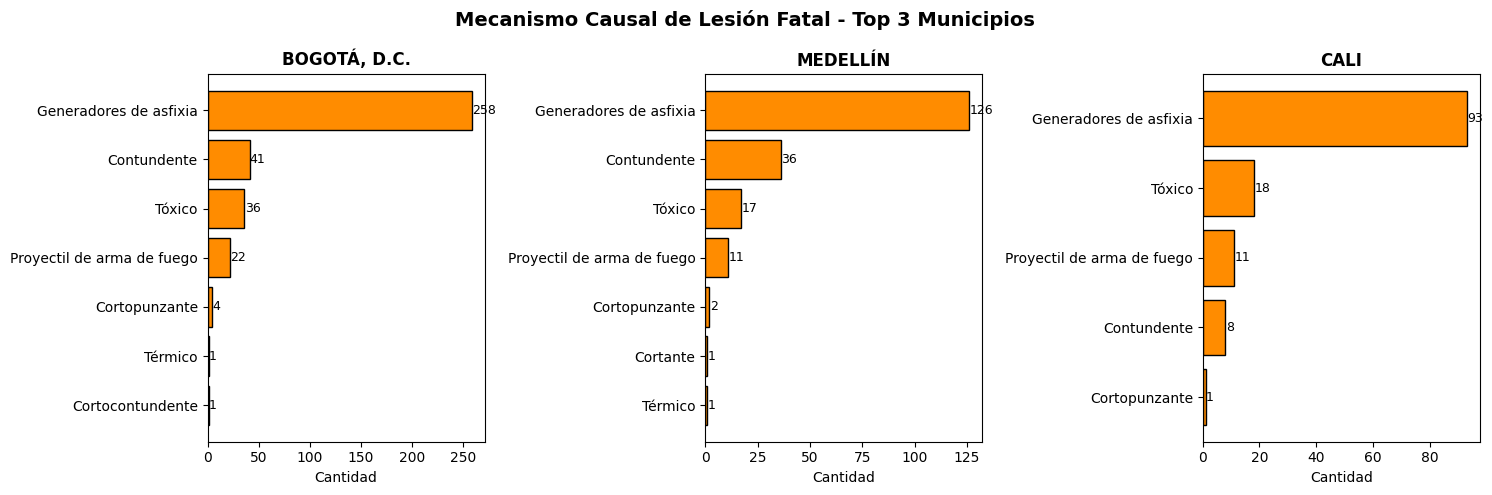

In [ ]:
# Para los 3 municipios con más datos
top3_municipios = df_suicidios_2024['Municipio del hecho DANE'].value_counts().head(3).index

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Mecanismo Causal de Lesión Fatal - Top 3 Municipios', fontsize=14, fontweight='bold')

for i, municipio in enumerate(top3_municipios):
    datos_mun = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'] == municipio]
    mecanismo_stats = datos_mun['Mecanismo Causal de la Lesión Fatal'].value_counts()

    # Barras horizontales
    axes[i].barh(mecanismo_stats.index, mecanismo_stats.values, color='darkorange', edgecolor='black')
    axes[i].set_title(municipio, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cantidad')
    axes[i].invert_yaxis()

    # Agregar valores
    for j, (bar, val) in enumerate(zip(axes[i].containers[0], mecanismo_stats.values)):
        axes[i].text(val + 0.2, j, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 9.Grafico de dispersion

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# 1. Agrupar delitos por municipio (sumando todas las categorías)
delitos_totales_por_municipio = df_delitos.groupby('MUNICIPIO')['CANTIDAD'].sum().reset_index()
delitos_totales_por_municipio.columns = ['MUNICIPIO', 'TOTAL_DELITOS']

# 2. Unir (merge) los DataFrames de suicidios y delitos por municipio
# Renombramos la columna de municipio en suicidios para que coincida
suicidios_por_municipio = suicidios_por_municipio.rename(columns={'Municipio del hecho DANE': 'MUNICIPIO'})

df_scatter = pd.merge(suicidios_por_municipio, delitos_totales_por_municipio, on='MUNICIPIO', how='inner')

# Ver las primeras filas para asegurarnos
print(df_scatter.head())

   MUNICIPIO  SUICIDIOS  PORCENTAJE  TOTAL_DELITOS
0      BELLO         45    1.493033         7662.0
1     SOACHA         32    1.061712        13597.0
2  FLORENCIA         23    0.763106           25.0
3    ARMENIA         22    0.729927           24.0
4    PALMIRA         21    0.696749         6902.0


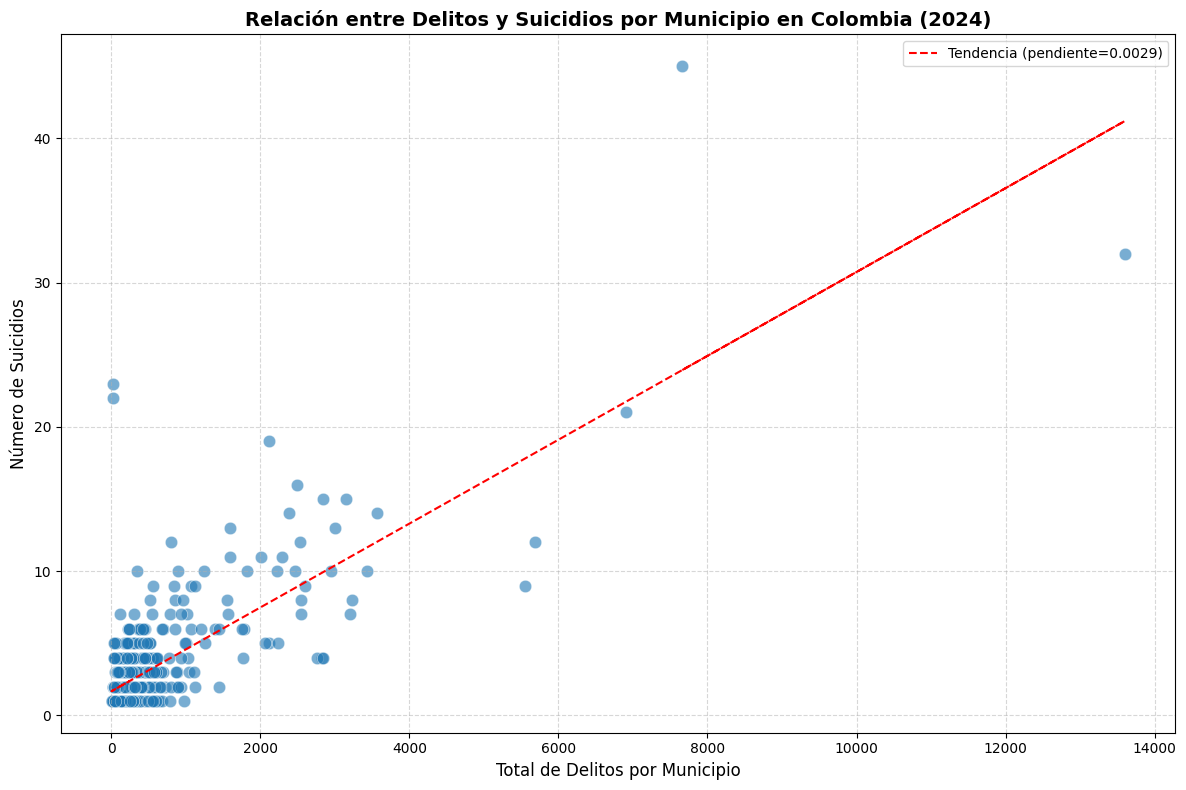


Correlación de Pearson entre delitos totales y suicidios: 0.7573


In [ ]:
plt.figure(figsize=(12, 8))

# Crear el scatter plot
plt.scatter(df_scatter['TOTAL_DELITOS'], df_scatter['SUICIDIOS'],
            alpha=0.6, edgecolors='w', linewidth=0.5, s=80)

# Etiquetas y título
plt.xlabel('Total de Delitos por Municipio', fontsize=12)
plt.ylabel('Número de Suicidios', fontsize=12)
plt.title('Relación entre Delitos y Suicidios por Municipio en Colombia (2024)',
          fontsize=14, fontweight='bold')

# Añadir una línea de tendencia (opcional, pero muy útil)
# Calculamos la regresión lineal (usando numpy)
z = np.polyfit(df_scatter['TOTAL_DELITOS'], df_scatter['SUICIDIOS'], 1)
p = np.poly1d(z)
plt.plot(df_scatter['TOTAL_DELITOS'], p(df_scatter['TOTAL_DELITOS']),
         color='red', linestyle='--', linewidth=1.5, label=f'Tendencia (pendiente={z[0]:.4f})')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Opcional: Calcular la correlación
correlacion = df_scatter['TOTAL_DELITOS'].corr(df_scatter['SUICIDIOS'])
print(f"\nCorrelación de Pearson entre delitos totales y suicidios: {correlacion:.4f}")

In [ ]:
# ==========================================
# 1. CREAR DataFrame CON DELITOS POR CATEGORÍA
# ==========================================

# Agrupar delitos por municipio y categoría
delitos_por_muni_cat = df_delitos.groupby(['MUNICIPIO', 'CATEGORIA'])['CANTIDAD'].sum().reset_index()

# Convertir a formato ancho (cada categoría es una columna)
pivot_delitos = delitos_por_muni_cat.pivot(index='MUNICIPIO', columns='CATEGORIA', values='CANTIDAD').fillna(0)

# Renombrar columnas
pivot_delitos.columns = [f'DELITO_{col.replace(" ", "_")}' for col in pivot_delitos.columns]
pivot_delitos = pivot_delitos.reset_index()

# ==========================================
# 2. UNIR CON SUICIDIOS
# ==========================================

# Calcular suicidios por municipio
suicidios_agg = df_suicidios_2024.groupby('Municipio del hecho DANE').size().reset_index(name='SUICIDIOS')

# Unir
df_scatter = suicidios_agg.merge(pivot_delitos,
                                  left_on='Municipio del hecho DANE',
                                  right_on='MUNICIPIO',
                                  how='inner')

# Calcular total de delitos (opcional)
delitos_cols = [col for col in df_scatter.columns if col.startswith('DELITO_')]
df_scatter['TOTAL_DELITOS'] = df_scatter[delitos_cols].sum(axis=1)

# Ver resultado
print("=== NUEVO df_scatter ===")
print(df_scatter.head())
print("\nColumnas disponibles:", df_scatter.columns.tolist())

=== NUEVO df_scatter ===
  Municipio del hecho DANE  SUICIDIOS  MUNICIPIO  DELITO_Delitos_Sexuales  \
0                ABEJORRAL          4  ABEJORRAL                     16.0   
1                  ACACÍAS          4    ACACÍAS                     77.0   
2                   ACANDÍ          2     ACANDÍ                      6.0   
3                  ACEVEDO          2    ACEVEDO                     14.0   
4                   AGRADO          1     AGRADO                      5.0   

   DELITO_Homicidios  DELITO_Hurto  DELITO_Lesiones_Personales  \
0               10.0          51.0                        78.0   
1               21.0         785.0                       639.0   
2                7.0           3.0                        20.0   
3               24.0         111.0                        83.0   
4                6.0          24.0                        50.0   

   DELITO_Otros_Delitos  DELITO_Secuestro  TOTAL_DELITOS  
0                  18.0               0.0          173.0

## 10.Grafico de dispersion suicidios vs categoria

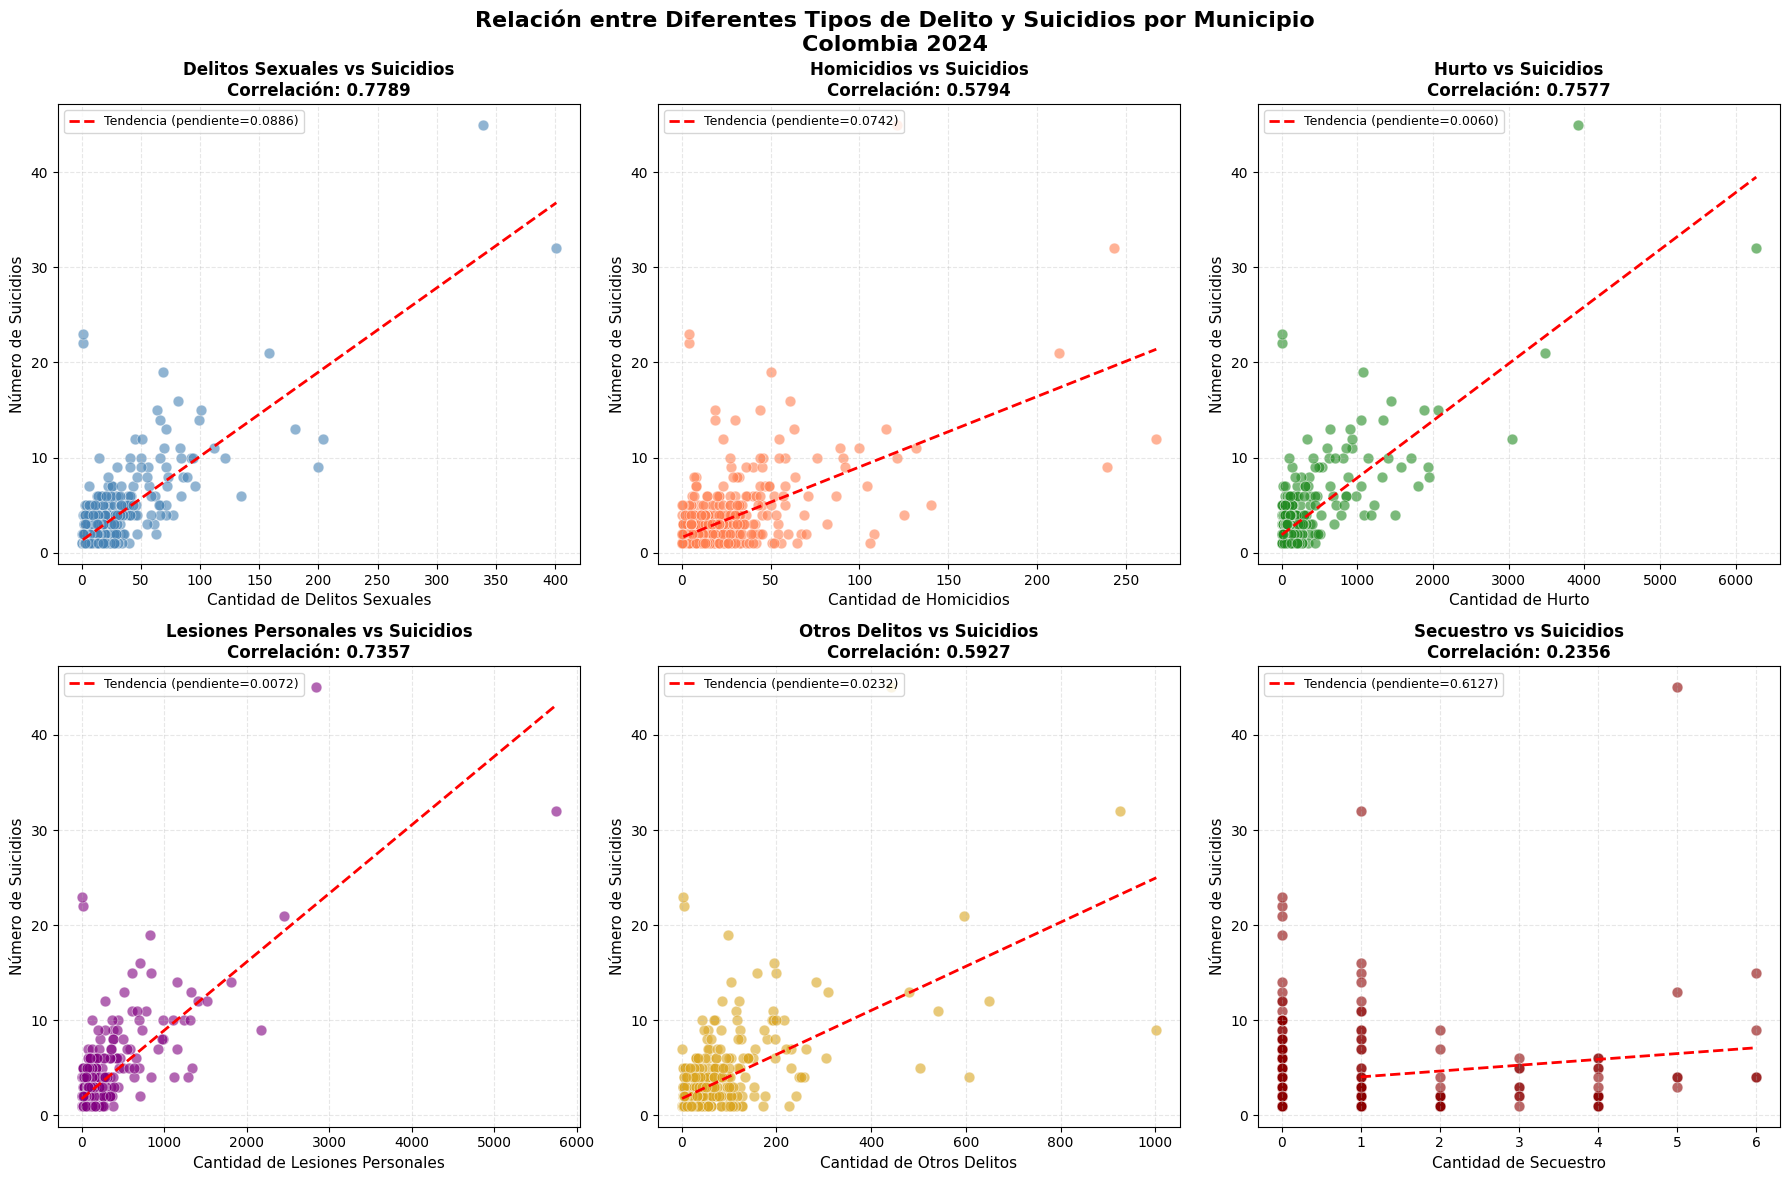

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Obtener columnas de delitos
delitos_cols = [col for col in df_scatter.columns if col.startswith('DELITO_')]
categorias = [col.replace('DELITO_', '').replace('_', ' ') for col in delitos_cols]

n_categorias = len(categorias)
n_cols = 3
n_rows = (n_categorias + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
axes = axes.flatten()

colors = ['steelblue', 'coral', 'forestgreen', 'purple', 'goldenrod', 'darkred']

for i, (delito_col, categoria, color) in enumerate(zip(delitos_cols, categorias, colors)):
    ax = axes[i]
    x = df_scatter[delito_col].values
    y = df_scatter['SUICIDIOS'].values

    ax.scatter(x, y, alpha=0.6, s=60, edgecolors='w', linewidth=0.5, color=color)

    mask = x > 0
    if mask.sum() > 1:
        z = np.polyfit(x[mask], y[mask], 1)
        p = np.poly1d(z)
        x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Tendencia (pendiente={z[0]:.4f})')

    corr = df_scatter[delito_col].corr(df_scatter['SUICIDIOS'])
    ax.set_xlabel(f'Cantidad de {categoria}', fontsize=11)
    ax.set_ylabel('Número de Suicidios', fontsize=11)
    ax.set_title(f'{categoria} vs Suicidios\nCorrelación: {corr:.4f}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Relación entre Diferentes Tipos de Delito y Suicidios por Municipio\nColombia 2024',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##  11.Modelo inicial solo con delitos

In [ ]:
pivot_delitos = df_delitos.pivot_table(
    index='MUNICIPIO',
    columns='CATEGORIA',
    values='CANTIDAD',
    aggfunc='sum',
    fill_value=0
).reset_index()

In [ ]:
suicidios_muni = df_suicidios_2024.groupby(
    'Municipio del hecho DANE'
).size().reset_index(name='suicidios')

In [ ]:
df_modelo = suicidios_muni.merge(
    pivot_delitos,
    left_on='Municipio del hecho DANE',
    right_on='MUNICIPIO',
    how='inner')

In [ ]:
import statsmodels.api as sm

y = df_modelo['suicidios']

X = df_modelo[[
    'Homicidios',
    'Secuestro',
    'Hurto',
    'Delitos Sexuales',
    'Lesiones Personales',
    'Otros Delitos'
]]

X = sm.add_constant(X)

modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:              suicidios   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     167.3
Date:                Wed, 20 May 2026   Prob (F-statistic):          1.73e-120
Time:                        22:06:00   Log-Likelihood:                -1226.3
No. Observations:                 556   AIC:                             2467.
Df Residuals:                     549   BIC:                             2497.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.4318    

##  12.Modelo con variables demoograficas

In [ ]:
sexo_dom = df_suicidios_2024.groupby('Municipio del hecho DANE')['Sexo de la victima'].agg(
    lambda x: x.value_counts().index[0]
).reset_index()

estado_dom = df_suicidios_2024.groupby('Municipio del hecho DANE')['Estado Civil'].agg(
    lambda x: x.value_counts().index[0]
).reset_index()

edad_dom = df_suicidios_2024.groupby('Municipio del hecho DANE')['Grupo Mayor Menor de Edad'].agg(
    lambda x: x.value_counts().index[0]
).reset_index()

escenario_dom = df_suicidios_2024.groupby('Municipio del hecho DANE')['Escenario del Hecho'].agg(
    lambda x: x.value_counts().index[0]
).reset_index()

In [ ]:
df_modelo = suicidios_muni.merge(
    pivot_delitos,
    left_on='Municipio del hecho DANE',
    right_on='MUNICIPIO',
    how='inner'
)

df_modelo = df_modelo.merge(sexo_dom, on='Municipio del hecho DANE', how='left')
df_modelo = df_modelo.merge(estado_dom, on='Municipio del hecho DANE', how='left')
df_modelo = df_modelo.merge(edad_dom, on='Municipio del hecho DANE', how='left')
df_modelo = df_modelo.merge(escenario_dom, on='Municipio del hecho DANE', how='left')

In [ ]:
import statsmodels.formula.api as smf

modelo_final = smf.ols(
'''
suicidios ~

Q("Delitos Sexuales") +
Q("Homicidios") +
Q("Hurto") +
Q("Lesiones Personales") +
Q("Otros Delitos") +
Q("Secuestro")

+

C(Q("Sexo de la victima")) +
C(Q("Estado Civil")) +
C(Q("Grupo Mayor Menor de Edad")) +
C(Q("Escenario del Hecho"))

''',
data=df_modelo
).fit()

print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:              suicidios   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     33.28
Date:                Wed, 20 May 2026   Prob (F-statistic):          4.24e-105
Time:                        22:06:01   Log-Likelihood:                -1206.6
No. Observations:                 556   AIC:                             2479.
Df Residuals:                     523   BIC:                             2622.
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                                                                                                                         coef    std err          t      P>|t|      [0.025      0.975]
-----------

## 13.Prueba VIF

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Variables explicativas (SIN SUICIDIOS)
X = df_modelo[['Delitos Sexuales', 'Homicidios', 'Hurto',
               'Lesiones Personales', 'Otros Delitos', 'Secuestro']]

# agregar constante
X = sm.add_constant(X)

# calcular VIF
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

              Variable        VIF
0                const   1.611561
1     Delitos Sexuales   8.593442
2           Homicidios   4.328663
3                Hurto  10.523059
4  Lesiones Personales  11.624235
5        Otros Delitos   5.610302
6            Secuestro   1.197709


## 14.Tes ramsey

In [ ]:
from statsmodels.stats.diagnostic import linear_reset
reset_test = linear_reset(modelo, power=2, use_f=True)

print(reset_test)

<F test: F=0.9587897002187225, p=0.32792407136935364, df_denom=548, df_num=1>


##  15.Corregir errores robustos

In [ ]:
df = df_modelo.copy()

In [ ]:
import statsmodels.formula.api as smf
modelo = smf.ols(
    'suicidios ~ Q("Sexo de la victima") + Q("Estado Civil") + Q("Grupo Mayor Menor de Edad") + Q("Escenario del Hecho") + Q("Delitos Sexuales") + Q("Homicidios") + Q("Hurto") + Q("Lesiones Personales") + Q("Otros Delitos") + Q("Secuestro")',
    data=df).fit(cov_type='HC1')   # arregla los errores robustos

In [ ]:
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:              suicidios   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     14.35
Date:                Wed, 20 May 2026   Prob (F-statistic):           1.01e-44
Time:                        22:06:01   Log-Likelihood:                -1206.6
No. Observations:                 556   AIC:                             2479.
Df Residuals:                     523   BIC:                             2622.
Df Model:                          32                                         
Covariance Type:                  HC1                                         
                                                                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
--------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 32, but rank is 25
  warnings.warn('covariance of constraints does not have full '


##  16.Correguir problemas de Multicolinealidad

In [ ]:
df_modelo['mujer'] = (df_modelo['Sexo de la victima'] == 'Mujer').astype(int)

df_modelo['mayor_edad'] = (df_modelo['Grupo Mayor Menor de Edad'].str.contains('Mayor')).astype(int)

df_modelo['soltero'] = (df_modelo['Estado Civil'] == 'Soltero(a)').astype(int)

df_modelo['escenario_urbano'] = df_modelo['Escenario del Hecho'].isin([
    'Vía pública',
    'Vivienda',
    'Establecimiento comercial (tienda, centro comercial, almacén)'
]).astype(int)

##  17.Modelo limpio

In [ ]:
X = df_modelo[[
    'Delitos Sexuales',
    'Homicidios',
    'Hurto',
    'Lesiones Personales',
    'Otros Delitos',
    'Secuestro',
    'mujer',
    'mayor_edad',
    'soltero',
    'escenario_urbano'
]]

X = sm.add_constant(X)

modelo = sm.OLS(df_modelo['suicidios'], X).fit(cov_type='HC1')
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:              suicidios   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     24.85
Date:                Wed, 20 May 2026   Prob (F-statistic):           8.34e-39
Time:                        22:06:01   Log-Likelihood:                -1211.3
No. Observations:                 556   AIC:                             2445.
Df Residuals:                     545   BIC:                             2492.
Df Model:                          10                                         
Covariance Type:                  HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.0279    